# 🏡 Predicting House Prices

## 0. Overview

This notebook aims to **analyze Portugal Real Estate data in order to build a reliable predictive model**. The model is tasked to **determine the price listing (in Euros) of a house property** based on numerous variables such as Area measurements, construction year, energy certificate, and many more. 

- Location / Geographical Coverage: **🇵🇹 Portugal** Real Estate
    - This data uses property listings on Portugal Real Estate websites. 

- Temporal Coverage: **🗓️ 2018 to 2024**
    - Dataset coverage began in April 2018 and was last updated in November 2024. *(While data was collected up to 2024, some houses were set to finish construction in the year 2025.)*

- Project Context: **Predict price of a given house to offer buyers**
    >  Your team is asked to create a machine learning model, which could predict the price for a given house. The pricing predictions API will be automated with events driven pipeline when new offer is being uploaded to any real estate system. If the price prediction of real estate will be lower than estimation, brokers will contact the owner immediately in order to buy it.

### 🎯 0.1 Objectives:

Target variable: `Price` of the real estate property

1. Train a regression model on the Portugal Housing prices
    * Evaluate different regression tree and boosted models
    * Practice stacked generalization modelling on the data
    * Determine best type of model
2. List which features are the most important to pricing
3. Deploy the model

### 🔎 Key Findings:
- Base Random Forest was a strong contender, beating base boosted models. However when tuned, RF's generalization worsened.  
- Both **tuned boosted models** (Light & Extreme Gradient Boosting) **and the Stacked ensemble were the top performers**, giving **up to ~€128k euro decreased improvement in MAE** from the baseline.
- Meta learner in stacked model showed marginal improvement and did not prove to be the best model in scoring.
- Light Gradient Boosting was chosen as the best model to deploy given its top score, and slight edge across all metrics as a singular model.
- The model was [successfully deployed](https://house-pricing-api-428580420970.europe-west1.run.app/docs)

Sources: Market Research 
- Can be used for benchmarks, comparisons, and general understanding of real estate market data:
    - [Portugal Property Market Outlook 2024](https://www.benoitproperties.com/news/portugal-property-market-outlook-2024/)
    - [Portugal's Residential Property Market Analysis](https://www.globalpropertyguide.com/europe/portugal/price-history)
    - [What are housing prices like in Portugal right now? (2026)](https://investropa.com/blogs/news/portugal-housing-prices)
    - [Portugal Homes Data](https://www.portugalhomes.com/news/article/592/portugal-house-prices)


Importing

In [281]:
from utils import *
import importlib
import os
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.stats import kruskal
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (IterativeImputer, SimpleImputer)
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
import joblib
import warnings
from sklearn.exceptions import SkipTestWarning
warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used",
    category=UserWarning,
)
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import shap
from sklearn.preprocessing import TargetEncoder

%matplotlib inline

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
palette = ["gray", "darkgoldenrod"]
sns.set_palette(["darkgoldenrod"])

In [282]:
df_import = pd.read_csv("dataset/portugal_listinigs.csv")
df = df_import.copy()

/tmp/ipykernel_46780/3264798250.py:1: DtypeWarning: Columns (9,10,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_import = pd.read_csv("dataset/portugal_listinigs.csv")


In [283]:
df.head()

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

* The given dataset has more than 135,000 entries and 25 features.

**Current features are as follows:** 

*(Note that select features will be dropped soon to lessen, noise, variance and other concerns for data modelling)*

**(For final variables, proceed to Section 2. "Features Revisited" in EDA section)**

- 🎯 Target Variable: Price - the asking price of the property in Euros
- 🌍️ Geographical Variables:
    - District
    - City
    - Town
- Type: Property type of real estate (House, Apartment, Mansion, etc)
- EnergyCertificate: The energy efficiency rating of the property, according to Portuguese energy certification standards. Ranges from A to F. (NC for No Certificate)
- EnergyEfficiencyLevel - same range and values as Certificate
- Area Measurements: Several columns related to the size and area of the property, including:
    - GrossPrivateArea: The private gross area of the property.
    - UsableArea: The area that can be used for living.
    - LivingArea: The actual livable space inside the property.
    - LotSize: The size of the land associated with the property.
    - BuiltArea: The total constructed area of the property.
- Room Variables - Detailed breakdowns of the number of rooms, bedrooms, bathrooms, and water closets in the property.
    - Rooms, 
    - Bedrooms, 
    - Bathrooms, 
    - WCs
- Floor: The floor on which the property is located.
- Parking, Garage: Information on parking availability and the presence of a garage.
- Amenities: Whether the property includes amenities like 
    - Elevator,
    - Garage,
    - Electric car charging stations
- ConstructionYear: The year the property was built.
- PublishDate: The date when the listing was published.

### 0.2 Dataset Overview - House Properties

This project focuses on house pricing predictions and its specific pricing dynamic.

Therefore only Type 'House' will be used as our dataset and the Type column will be dropped:

In [285]:
df["Type"].value_counts()

Type
Apartment              47378
House                  36736
Land                   31843
Store                   5333
Farm                    3889
Building                2491
Transfer of lease       1646
Warehouse               1444
Garage                   976
Other - Commercial       816
Office                   725
Other - Residential      599
Industrial               441
Duplex                   393
Investment               255
Storage                  203
Hotel                    161
Studio                    87
Estate                    64
Mansion                   33
Manor                      7
Name: count, dtype: int64

In [286]:
df = df[df["Type"] == "House"].drop(columns=["Type"])
df.head()

,Price,District,City,Town,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,Floor,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
15,175000.0,Faro,Faro,Faro (Sé e São Pedro),NC,NaN,78.0,0.0,False,NaN,...,False,NaN,4.0,NaN,NaN,NaN,78.0,NaN,NaN,2.0
20,435000.0,Faro,Loulé,São Clemente,D,NaN,226.0,2.0,True,Ground Floor,...,False,NaN,3.0,NaN,NaN,NaN,184.0,NaN,NaN,2.0
23,605000.0,Faro,Albufeira,Albufeira e Olhos de Água,C,113.0,640.0,2.0,True,NaN,...,False,NaN,3.0,NaN,NaN,NaN,113.0,NaN,NaN,3.0
24,1485000.0,Faro,Loulé,Quarteira,D,NaN,472.0,2.0,True,Ground Floor,...,False,NaN,4.0,NaN,NaN,NaN,414.0,NaN,NaN,5.0
28,195000.0,Faro,Vila do Bispo,Vila do Bispo e Raposeira,NC,110.0,137.0,0.0,False,NaN,...,False,NaN,0.0,NaN,NaN,NaN,110.0,NaN,NaN,0.0


In [287]:
df.shape

(36736, 24)

In [288]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,36652.0,453562.548101,7.233478e+06,1.0,105000.000,259250.0,480000.00,1.380000e+09
GrossArea,9423.0,453.221479,6.766363e+03,0.0,134.000,220.0,317.00,4.703000e+05
TotalArea,36730.0,1917.430792,5.481444e+04,0.0,120.000,211.0,409.75,5.525000e+06
Parking,36617.0,0.892673,1.041159e+00,0.0,0.000,1.0,1.00,3.000000e+00
ConstructionYear,34315.0,1982.321434,2.909666e+01,1900.0,1951.000,1987.0,2006.00,2.025000e+03
TotalRooms,27316.0,4.089911,1.678343e+01,0.0,3.000,4.0,5.00,2.751000e+03
NumberOfBedrooms,18016.0,3.358626,1.609987e+00,0.0,3.000,3.0,4.00,2.100000e+01
NumberOfWC,16223.0,0.662948,1.108552e+00,0.0,0.000,0.0,1.00,1.400000e+01
LivingArea,36725.0,327.964193,5.279510e+03,0.0,96.000,157.0,234.00,4.703000e+05
LotSize,14159.0,4136.166890,8.315671e+04,0.0,215.000,434.0,1032.00,5.525000e+06


Significant missing values and anomalous maximums. Price is heavily skewed with such a large standard deviation.

🗒️ The dataset on housing has **more than 36,000 entries** and **24 features**

## 1. Data Cleaning

In [289]:
print("Null values in the df: ", df.isna().sum().sum())
percent_nulls = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Percent of missing values present: {percent_nulls:.2f}%")

print("Duplicate values in the df: ", df.duplicated().sum())
percent_duplicates = (df.duplicated().sum() / len(df)) * 100
print(f"Percent of duplicates present: {percent_duplicates:.2f}%")

Null values in the df:  298336
Percent of missing values present: 33.84%
Duplicate values in the df:  2194
Percent of duplicates present: 5.97%


⚠️ Upwards of **33%, about 1/3 of our data, is missing** / null. And 6% are duplicates.

### 1.1 Duplicates

Data was taken from several online platforms so duplicates of the same listing are likely - duplicates will be dropped.

In [290]:
df.drop_duplicates(keep="first", inplace=True)
print(f"Clean shape after dedupe: {df.shape}")

Clean shape after dedupe: (34542, 24)


### 1.2 Null, Missing and Inconsistent Values

In this section we will meticulously check through the features for:
- inconsistent or incorrect values (e.g. negative prices), 
- anomaly data (extreme outliers, other outliers),
- nulls and zeroes

In [291]:
missing = pd.DataFrame(
    {"count": df.isna().sum(), "percentage": round(df.isna().sum() / len(df) * 100, 1)}
).sort_values("percentage", ascending=False)

print(missing)

                       count  percentage
Floor                  33543        97.1
ConservationStatus     28701        83.1
PublishDate            27056        78.3
BuiltArea              26088        75.5
GrossArea              25638        74.2
LotSize                21295        61.6
NumberOfWC             19346        56.0
Garage                 17642        51.1
NumberOfBedrooms       17645        51.1
ElectricCarsCharging   17642        51.1
EnergyEfficiencyLevel  17642        51.1
HasParking             16906        48.9
TotalRooms              8889        25.7
ConstructionYear        2010         5.8
NumberOfBathrooms        286         0.8
Price                     77         0.2
Parking                   74         0.2
TotalArea                  6         0.0
City                       0         0.0
Town                       0         0.0
District                   0         0.0
EnergyCertificate          0         0.0
Elevator                   6         0.0
LivingArea      

🗑️ Dropping columns: 

1. **Sub-features will be dropped** - *these are slightly repetitive features that carry less critical data, were found to be multicollinear or more incomplete than their counterpart, and where similar data is already given by other variables:*
    - `Publish Date` dropped (in favor of using more complete ConstructionYear)
    - `HasParking` boolean dropped (Parking variable int tells more)
    - `EnergyEfficiencyLevel` dropped. It had the same data as EnergyCertificate but missing
    - `NumberOfWC` < NumberOfBathrooms

2. **Features with more than 60% null** will be dropped as well:
    - `BuiltArea`, `GrossArea` and `LotSize` 
    - `Floor` (not fully applicable for houses of multiple floors) and `ConservationStatus` have 80% up to almost 100% missing. 

While the columns above may have been telling of a property price (LotSize as a posisble contributor to pricing), are unfortunately too void to be accurate or useful for generalizing. These also cannot be guessed or are safe to impute (i.e. we cannot assume Conservation Status or state that a house is "Like New", even based on year) 

Thankfully there are still other relative variables that can be used in place of those dropped, such as TotalArea & LivingArea can still be used for valuable data on property measurements.

In [292]:
df = df.drop(
    columns=[
        "PublishDate",
        "HasParking",
        "EnergyEfficiencyLevel",
        "NumberOfWC",
        "BuiltArea",
        "GrossArea",
        "LotSize",
        "Floor",
        "ConservationStatus",
    ]
)

**Reordering columns** so that related ones are beside one other, and more telling / pertinent data appear first (bring area measurements and construction year to earlier columns, amenities last)

In [293]:
column_order = [
    "Price",
    "District",
    "City",
    "Town",
    "EnergyCertificate",
    "TotalArea",
    "LivingArea",
    "ConstructionYear",
    "TotalRooms",
    "NumberOfBedrooms",
    "NumberOfBathrooms",
    "Parking",
    "Garage",
    "Elevator",
    "ElectricCarsCharging",
]
df = df[column_order]

Viewing values per feature:

In [294]:
print(df.apply(lambda col: col.unique()))

Price                   [175000.0, 435000.0, 605000.0, 1485000.0, 1950...
District                [Faro, Guarda, Viseu, Coimbra, Leiria, Castelo...
City                    [Faro, Loulé, Albufeira, Vila do Bispo, Vila R...
Town                    [Faro (Sé e São Pedro), São Clemente, Albufeir...
EnergyCertificate       [NC, D, C, B-, A, E, F, B, A+, G, Not availabl...
TotalArea               [78.0, 226.0, 640.0, 472.0, 137.0, 63.0, 211.0...
LivingArea              [78.0, 184.0, 113.0, 414.0, 110.0, 63.0, 135.0...
ConstructionYear        [1950.0, 1958.0, 1976.0, 2004.0, 1937.0, nan, ...
TotalRooms              [4.0, 3.0, 0.0, 1.0, 2.0, 6.0, 7.0, 5.0, 8.0, ...
NumberOfBedrooms        [nan, 2.0, 0.0, 4.0, 3.0, 6.0, 5.0, 7.0, 9.0, ...
NumberOfBathrooms       [2.0, 3.0, 5.0, 0.0, 1.0, 6.0, 4.0, 7.0, nan, ...
Parking                                         [0.0, 2.0, 1.0, 3.0, nan]
Garage                                                 [nan, False, True]
Elevator                              

There are null values across much of the features.

#### Target Variable: Price (Nulls)
Begin cleaning by dropping where target variable = invalid (0 or negative). Null price values will be kept for now that the API / model may find useful. 

In [295]:
df = df[df["Price"].notna() & (df["Price"] > 0)]

Price will be further cleaned *after* the rest of the variables given its dependency

#### Geographical Data
Geographical data (District, City, Town) was checked off-notebook for encoding errors, near duplicates or typographical errors and only a handful were found.

Introducing minor fixes here for encoding errors:

In [296]:
df["Town"] = df["Town"].str.replace(
    "Vila Cova Ã  Coelheira", "Vila Cova à Coelheira", regex=False
)

df["Town"] = df["Town"].str.replace("Constance", "Constância", regex=False)

df.loc[df["Town"] == "Ãzere", "Town"] = "Ázere e Covelo"

#### Energy Certificate

In [297]:
df["EnergyCertificate"].value_counts()

EnergyCertificate
NC                10414
E                  5191
F                  4816
D                  4714
C                  3121
A                  2262
A+                 1484
B                  1243
B-                 1039
G                   160
No Certificate       15
Not available         6
Name: count, dtype: int64

Mapping nulls, "No certificate" or "not available" to `NC` (the given tag for No Certificate) for uniformity.

In [298]:
df["EnergyCertificate"] = (
    df["EnergyCertificate"]
    .fillna("NC")
    .replace({"No Certificate": "NC", "Not available": "NC"})
)

For model usage: Energy Certificate int column
* Translating and mapping to int (`EnergyCertNum`) for the model later. 
    * Assigning in order where NC = 0, up to A+ = 9
    * Higher = more efficient
* Otherwise we will use the Str version (`EnergyCertificate`) for visualization.

In [299]:
energy_map = {
    "NC": 0,
    "G": 1,
    "F": 2,
    "E": 3,
    "D": 4,
    "C": 5,
    "B-": 6,
    "B": 7,
    "A": 8,
    "A+": 9,
}

df["EnergyCertNum"] = df["EnergyCertificate"].map(energy_map)

#### Construction Year

`ConstructionYear` has a few null values (~2k). These will be dropped from the dataset.

In [300]:
df = df.dropna(subset=["ConstructionYear"])

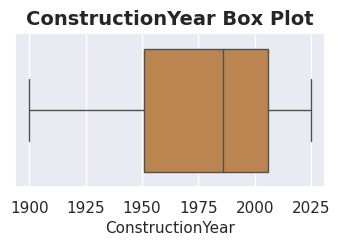

In [301]:
plt.figure(figsize=(4, 2))
sns.boxplot(df, x="ConstructionYear", color="peru")
plt.title("ConstructionYear Box Plot")
plt.show()

No anomalies or outliers were found in ConstructionYear

#### Room Number Variables
1. TotalRooms
2. NumberOfBedrooms
3. NumberOfBathrooms

In [302]:
room_vars = ["TotalRooms", "NumberOfBedrooms", "NumberOfBathrooms"]
df[room_vars] = df[room_vars].astype("Int64")
df[room_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalRooms,23923.0,4.104209,17.91583,0.0,3.0,4.0,5.0,2751.0
NumberOfBedrooms,16199.0,3.348972,1.639663,0.0,2.0,3.0,4.0,21.0
NumberOfBathrooms,32202.0,2.291442,1.857136,-1.0,1.0,2.0,3.0,131.0


In [303]:
null_counts = df[room_vars].isna().sum()

invalid_counts = df[room_vars].apply(lambda x: ((x.isnull()) | (x <= 0)).sum())

summary = pd.DataFrame({"NullCount": null_counts, "InvalidCount": invalid_counts})
summary["InvalidPct"] = (summary["InvalidCount"] / len(df) * 100).round(2).astype(
    str
) + "%"

print(summary)

                   NullCount  InvalidCount InvalidPct
TotalRooms              8550          9028      27.8%
NumberOfBedrooms       16274         16664     51.32%
NumberOfBathrooms        271          4419     13.61%


The data on bathrooms is our most complete variable. 

🗑️ **Rows where *all* room variables are null or 0**, where there is no data present, **will be dropped.**

In [304]:
empty_room_data = df[room_vars].eq(0).fillna(True).all(axis=1)
print(f"Dropping {empty_room_data.sum()} null and invalid room data")
df = df[~empty_room_data]

Dropping 622 null and invalid room data


Removing the extreme outlier anomalies (all of which were further checked off-notebook): a house with 2k total rooms, 130 bathrooms and anomaly -1 bathroom

In [305]:
df.drop(df["TotalRooms"].idxmax(), inplace=True)
df.drop(df["NumberOfBathrooms"].idxmin(), inplace=True)
df.drop(df["NumberOfBathrooms"].idxmax(), inplace=True)

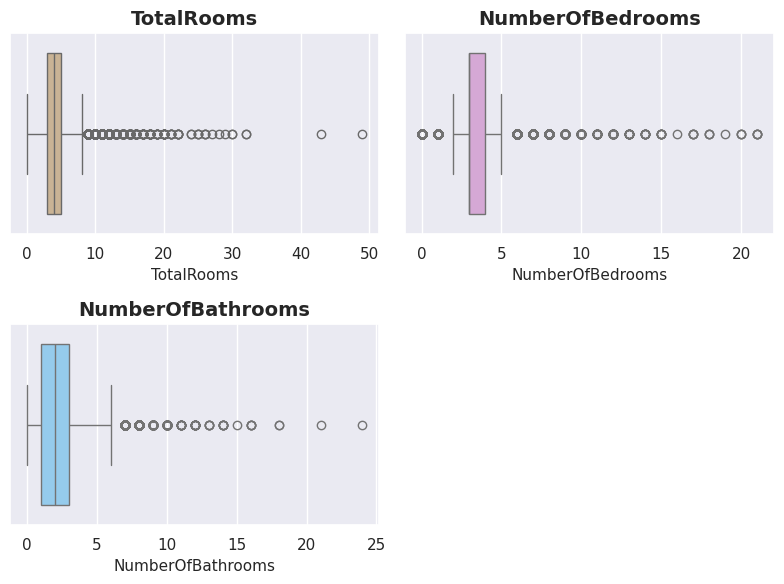

In [306]:
plt.figure(figsize=(8, 6))
room_colors = ["tan", "plum", "lightskyblue"]
for i, col in enumerate(room_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color=room_colors[i - 1])
    plt.title(col)
plt.tight_layout()
plt.show()

Upwards of 50, 20, and 25 in different room types that suggests non-House properties.

#### Removing Outliers in All Room Variables

Outliers will be dropped since such high reaching maximums and outliers in area measurements suggest another Type of property besides `House` and these can be considered mansion, manor, etc. types not supposedly included.

In [307]:
Q1 = df[room_vars].quantile(0.25)
Q3 = df[room_vars].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[room_vars] < lower_bound).any(axis=1) | (
    df[room_vars] > upper_bound
).any(axis=1)

print(f"Dropping {outlier_mask.sum()} outlier rows")
df = df[~outlier_mask]
print(f"New shape: {df.shape}")

Dropping 2927 outlier rows
New shape: (28921, 16)


For our house property deals, we will **only consider houses where there are at least 1 totalrooms, 1 bedroom and 1 bath** - 0s in any room variables will be dropped

In [308]:
zero_mask = (df[room_vars] == 0).any(axis=1)
print(f"Dropping {zero_mask.sum()} == 0 rows")
df = df[~zero_mask]

Dropping 3205 == 0 rows


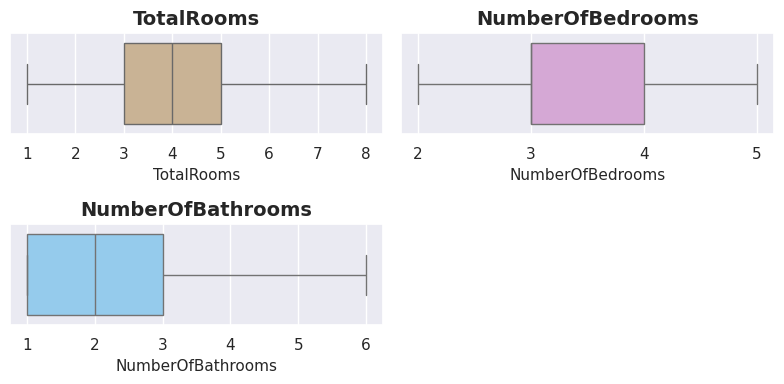

In [309]:
plt.figure(figsize=(8, 4))
for i, col in enumerate(room_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color=room_colors[i - 1])
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.title(col)
plt.tight_layout()
plt.show()

Range of rooms went from ~50s and 20s to 8, 5 and 6.

In [310]:
df[room_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalRooms,19331.0,3.762609,1.413328,1.0,3.0,4.0,5.0,8.0
NumberOfBedrooms,12119.0,3.240779,0.888921,2.0,3.0,3.0,4.0,5.0
NumberOfBathrooms,25499.0,2.482058,1.301702,1.0,1.0,2.0,3.0,6.0


For the missing data in TotalRooms and Bedrooms, during model preprocessing, `IterativeImputer` will be used for these interdependent and related room variables.

#### Area Variables

Area Measurements: 2 columns related to the size and area of the property:
- `TotalArea`
- `LivingArea`

📏 **Minimum measurement: 35 square meters** 
- 35 square meters will be considered as smallest comfortable home measurement. This is according to [Portugal conditions of minimum living area](https://www.buyhouse-portugal.com/en/properties/typologies). Anything below will be considered invalid for our living spaces.

In [311]:
area_vars = ["TotalArea", "LivingArea"]
area_colors = ["royalblue", "deepskyblue"]

null_counts = df[area_vars].isna().sum()

invalid_mask = df[area_vars].isna() | (df[area_vars] < 35)
invalid_counts = invalid_mask.sum()

summary = pd.DataFrame({"NullCount": null_counts, "InvalidCount": invalid_counts})
summary["InvalidPct"] = (summary["InvalidCount"] / len(df) * 100).round(2).astype(
    str
) + "%"

print(summary)

            NullCount  InvalidCount InvalidPct
TotalArea           0           228      0.89%
LivingArea          2           313      1.22%


Dropping where there is invalid data in either of the area features:

In [312]:
invalid_mask = df[area_vars].isna() | (df[area_vars] < 35)

df = df[~invalid_mask.any(axis=1)]
print(f"Dropping {invalid_mask.sum().sum()} null and invalid area")
print(f"New shape: {df.shape}")

Dropping 541 null and invalid area
New shape: (25290, 16)


Outliers in Area Vars

With the same logic for room variables we will drop outliers in area measurements as well since it suggest non-House types

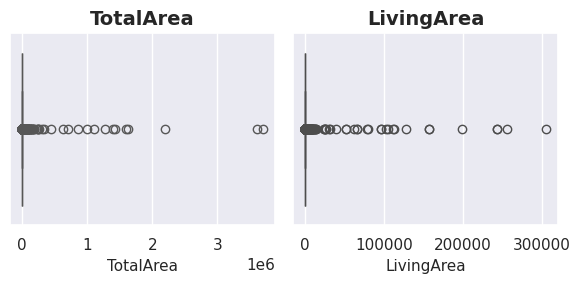

In [313]:
plt.figure(figsize=(6, 3))
for i, col in enumerate(area_vars, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col], color=area_colors[i - 1])
    plt.title(col)
plt.tight_layout()
plt.show()

Large-stretching outliers that need to be addressed such as Total Area going up to millions in square meters.

In [314]:
Q1 = df[area_vars].quantile(0.25)
Q3 = df[area_vars].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[area_vars] < lower_bound).any(axis=1) | (
    df[area_vars] > upper_bound
).any(axis=1)

print(f"Dropping {outlier_mask.sum()} outlier rows")
df = df[~outlier_mask]
print(f"New shape: {df.shape}")

Dropping 4005 outlier rows
New shape: (21285, 16)


Observing where TotalArea < LivingArea - needs to be fixed

In [315]:
len(df[df["TotalArea"] < df["LivingArea"]])

2900

In [316]:
mask = df["TotalArea"] < df["LivingArea"]

df[mask].head()

,Price,District,City,Town,EnergyCertificate,TotalArea,LivingArea,ConstructionYear,TotalRooms,NumberOfBedrooms,NumberOfBathrooms,Parking,Garage,Elevator,ElectricCarsCharging,EnergyCertNum
49,420000.0,Faro,Portimão,Alvor,D,140.0,158.0,1998.0,6,<NA>,5,1.0,NaN,False,NaN,4
95,305000.0,Faro,Silves,Silves,E,160.0,200.0,2011.0,3,<NA>,2,0.0,NaN,False,NaN,3
169,395000.0,Faro,Lagos,São Gonçalo de Lagos,C,67.0,108.0,1986.0,3,<NA>,2,0.0,NaN,False,NaN,5
185,380000.0,Faro,Lagoa (Algarve),Estômbar e Parchal,D,126.0,156.0,2005.0,3,<NA>,3,0.0,NaN,False,NaN,4
189,650000.0,Faro,Loulé,Quarteira,C,157.0,193.0,2007.0,3,<NA>,4,2.0,NaN,False,NaN,5


It is concerning that there are a few thousand (2,900) data entries where TotalArea < LivingArea - **we will consider these mismatched and swap these values.**

(*Another possible concern is where there is a large difference between the two (e.g. 50 vs. 400). However upon research, these are plausible, such as farmhouses that come with large lots for sale. Take for example [this farmhouse listing](https://www.green-acres.pt/en/properties/property/faro-se-e-sao-pedro/Ad4qwzy8pp3iraxg.htm) - a farmhouse where surface area is 25 m² and total land area is 6720m² with 2 bedrooms and 1 bath. These will be kept as valid and removed later if detected as outliers.*)

In [317]:
df.loc[mask, area_vars] = df.loc[mask, area_vars[::-1]].values

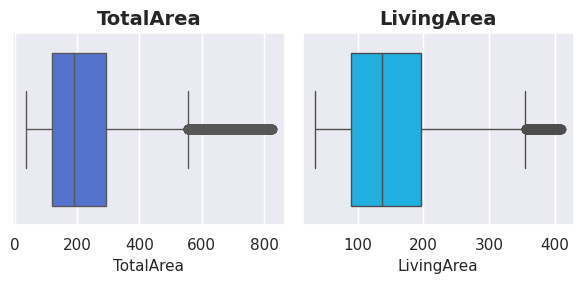

In [318]:
plt.figure(figsize=(6, 3))
for i, col in enumerate(area_vars, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col], color=area_colors[i - 1])
    plt.title(col)
plt.tight_layout()
plt.show()

These measurements seem sensible for our housing dataset. 

🎾 For scale, LivingArea reaches up to a maximum ~400 square meters which is a house about the size of 2 standard tennis courts - a sensible reach for our data.

In [319]:
df[area_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalArea,21285.0,230.674090,153.828759,35.0,120.0,190.0,294.0,826.0
LivingArea,21285.0,149.369274,75.945299,35.0,90.0,137.0,196.0,410.0


#### Target Variable: Price check & Cleaning

With the other variables treated, we can return to our dependent variable and check the remaining anomalies here.

In [320]:
df["Price"].describe()

count    2.128500e+04
mean     4.279072e+05
std      9.465981e+06
min      6.900000e+03
25%      1.200000e+05
50%      2.500000e+05
75%      4.395000e+05
max      1.380000e+09
Name: Price, dtype: float64

In [321]:
print(df["Price"].nsmallest(5))

66080    6900.0
76066    6900.0
18591    7250.0
76958    7250.0
1613     7500.0
Name: Price, dtype: float64


In [322]:
print(df["Price"].nlargest(5))

58787    1.380000e+09
95318    1.000000e+07
66692    8.500000e+06
61100    7.400000e+06
82496    5.500000e+06
Name: Price, dtype: float64


Dropping the largest value 1 billion euro home

In [323]:
df.drop([df["Price"].idxmax()], inplace=True)

#### Price Per Square Meter

**Price outliers:**

Instead of outright removing price outliers, the lowest and highest percentiles in `Price Per Square Meter` will be removed. This will effectively **remove any unbalancing / impossible combinations between Price and Area.** 

This method **keeps million-dollar value homes to sell luxury deals**, but removes most unlikely values.

In [324]:
df["PricePerSqm"] = df["Price"] / (df["TotalArea"])

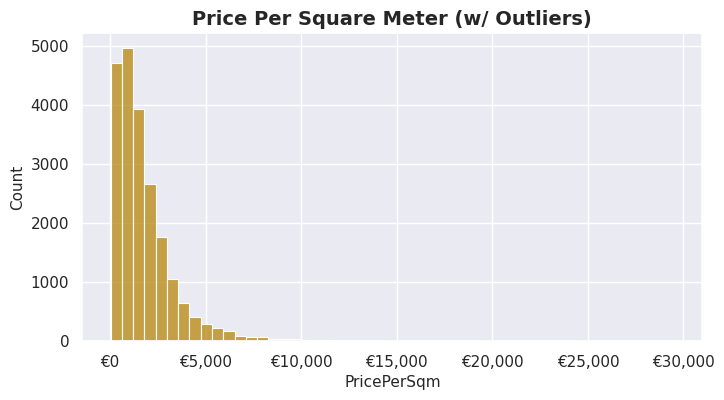

In [325]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="PricePerSqm", bins=50)
fmt_price_axis(plt.gca())
plt.title("Price Per Square Meter (w/ Outliers)")
plt.show()

Dropping the most unlikely price per square meter boundary homes (Bottom 1% and Top 99%):

In [326]:
lower_bound = df["PricePerSqm"].quantile(0.01)
upper_bound = df["PricePerSqm"].quantile(0.99)

clean_mask = (df["PricePerSqm"] >= lower_bound) & (df["PricePerSqm"] <= upper_bound)

print(f"Data errors to remove: {len(df) - len(df[clean_mask])} over {len(df)}")

df = df[clean_mask]

Data errors to remove: 426 over 21284


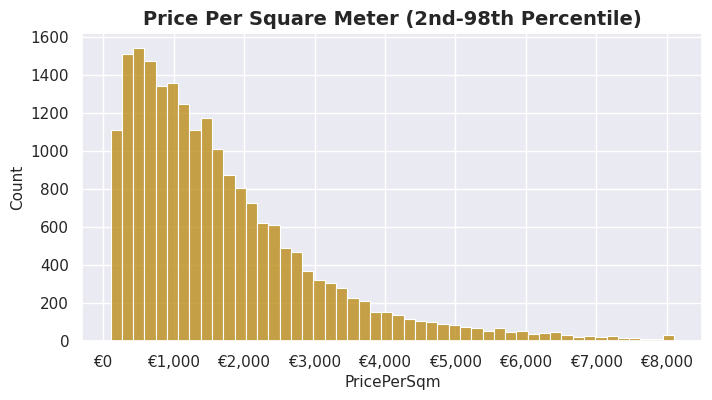

In [327]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="PricePerSqm", bins=50)
fmt_price_axis(plt.gca())
plt.title("Price Per Square Meter (2nd-98th Percentile)")
plt.show()

Reduced to more sensible distribution of up to 8,000 euro per square meter as our maximum.

In [328]:
df["Price"].nsmallest()

76066     6900.0
65518     8000.0
77721     8000.0
129743    8000.0
76001     9900.0
Name: Price, dtype: float64

In [329]:
df["Price"].nlargest()

84659    4950000.0
36405    4200000.0
36412    4200000.0
40435    3995000.0
37661    3990000.0
Name: Price, dtype: float64

In [330]:
print(df.loc[df["Price"] <= 20000, ["Price", "PricePerSqm", "TotalArea"]].head())

        Price  PricePerSqm  TotalArea
1661  14500.0   295.918367       49.0
1672  15000.0   150.000000      100.0
1893  19000.0   218.390805       87.0
1896  19900.0   160.483871      124.0
1912  14000.0   164.705882       85.0


Considerably adjusted the price per square meter to reasonable limits. 

Upwards of 4 million Euro valued homes remain as our higher priced sellings.

#### Misc. Variables -  Imputing with Default Values

For the rest of the variables, **NaN values will be filled with applicable defaults**: 0, False, Unknown, etc and **ultimately turned into 0s**.

In [331]:
df["Parking"] = df["Parking"].fillna(0)
df["Garage"] = df["Garage"].fillna(False)
df["Elevator"] = df["Elevator"].fillna(False)
df["ElectricCarsCharging"] = df["ElectricCarsCharging"].fillna(False)

/tmp/ipykernel_46780/782421513.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Garage"] = df["Garage"].fillna(False)
/tmp/ipykernel_46780/782421513.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Elevator"] = df["Elevator"].fillna(False)
/tmp/ipykernel_46780/782421513.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[

In [332]:
bool_vars = ["Garage", "Elevator", "ElectricCarsCharging"]

df[bool_vars] = df[bool_vars].astype(int)

Check if any mixed data types remain

In [333]:
for col in df.columns:
    types = df[col].apply(type).unique()
    if len(types) > 1:
        print(f"{col}: {types}")

### Data Cleaning Summary

In [334]:
print("Null values: ", df.isna().sum().sum())
percent_nulls = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Percent of missing values present: {percent_nulls:.2f}%")

print("Duplicate values: ", df.duplicated().sum())
percent_duplicates = (df.duplicated().sum() / len(df)) * 100
print(f"Percent of duplicates present: {percent_duplicates:.2f}%")

Null values:  15690
Percent of missing values present: 4.42%
Duplicate values:  382
Percent of duplicates present: 1.83%


✅ Improved from 30% missing data to ~4% missing

A few more duplicates were revealed after translating nulls to drop (i.e. Garage: NaN, Parking 0 --> Garage: 0, Parking 0 now revealed more duplicates across all values) 

In [335]:
df.drop_duplicates(inplace=True)

Saving our cleaned dataset for production recreation purposes

In [336]:
df.to_csv("dataset/house_listings_cleaned.csv", index=False)

🗑️ Dropped features:
- PublishDate
- HasParking
- EnergyEfficiencyLevel
- GrossArea
- BuiltArea
- LotSize
- Floor
- ConservationStatus
- NumberOfWC

🗒️ Decisions made:
- Area meaasurements:
    - 📏 Requirement: 35+ sqm. - Properties less than 35 square meters were dropped according to Portugal measurement standards.
    - Swapping TotalArea and LivingArea and ensuring TotalArea > LivingArea for consistent measurements. 
    - Rows with invalid or no data  in either 2 area measurements were dropped. Outliers as well.
- Room number variables:
    - Requirement: at least 1 Room, 1BR, 1BA - Only properties with at least 1 total rooms, bedroom and bathroom are considered = All properties have at least 1 bedroom and bath.
    - Rows with no data across room variables, were dropped. Outliers as well.
- `Parking` and Amenities variables (Garage, Elevator, Car charging) are now ints (either 0 or 1) - False and 0s were defaulted

- 📌 Target Variable: `Price` Cleaning
    - New feature `PricePerSqm` was introduced
    - High-valued homes (price outliers) remain, however,
    - Outliers in price per square meter of the highest degree (1st & 99th percentile) were dropped

To-do: Missing room variables (TotalRooms, NumberOfBedrooms) will be imputed in the model pipeline through Iterative imputing. Other missing variables will use other types of Imputers (Simple)

## 2. Exploratory Data Analysis

In [337]:
df.head()

,Price,District,City,Town,EnergyCertificate,TotalArea,LivingArea,ConstructionYear,TotalRooms,NumberOfBedrooms,NumberOfBathrooms,Parking,Garage,Elevator,ElectricCarsCharging,EnergyCertNum,PricePerSqm
15,175000.0,Faro,Faro,Faro (Sé e São Pedro),NC,78.0,78.0,1950.0,4,<NA>,2,0.0,0,0,0,0,2243.589744
20,435000.0,Faro,Loulé,São Clemente,D,226.0,184.0,1958.0,3,<NA>,2,2.0,0,0,0,4,1924.778761
23,605000.0,Faro,Albufeira,Albufeira e Olhos de Água,C,640.0,113.0,1976.0,3,<NA>,3,2.0,0,0,0,5,945.312500
41,96500.0,Faro,Vila Real de Santo António,Vila Nova de Cacela,NC,211.0,135.0,1950.0,2,<NA>,1,0.0,0,0,0,0,457.345972
42,325000.0,Faro,Vila Real de Santo António,Vila Nova de Cacela,D,110.0,102.0,2004.0,3,<NA>,3,1.0,0,0,0,4,2954.545455


In [338]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,20476.0,342766.208195,352685.591269,6900.0,124900.0,250000.0,429125.0,4950000.0
TotalArea,20476.0,228.60881,152.354551,35.0,120.0,189.0,292.0,826.0
LivingArea,20476.0,148.584685,75.718815,35.0,89.0,136.0,195.0,410.0
ConstructionYear,20476.0,1984.93026,27.802224,1900.0,1961.75,1989.0,2007.0,2025.0
TotalRooms,14740.0,3.778358,1.418498,1.0,3.0,4.0,5.0,8.0
NumberOfBedrooms,10873.0,3.218063,0.880559,2.0,3.0,3.0,4.0,5.0
NumberOfBathrooms,20322.0,2.407489,1.230539,1.0,1.0,2.0,3.0,6.0
Parking,20476.0,0.785847,0.951984,0.0,0.0,1.0,1.0,3.0
Garage,20476.0,0.216693,0.412002,0.0,0.0,0.0,0.0,1.0
Elevator,20476.0,0.008156,0.089943,0.0,0.0,0.0,0.0,1.0


- Working with ~20,000 data entries.
- Price standard deviation is about 350k euro, considerably narrowed from earlier thanks to data cleaning.

In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20476 entries, 15 to 135534
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 20476 non-null  float64
 1   District              20476 non-null  object 
 2   City                  20476 non-null  object 
 3   Town                  20476 non-null  object 
 4   EnergyCertificate     20476 non-null  object 
 5   TotalArea             20476 non-null  float64
 6   LivingArea            20476 non-null  float64
 7   ConstructionYear      20476 non-null  float64
 8   TotalRooms            14740 non-null  Int64  
 9   NumberOfBedrooms      10873 non-null  Int64  
 10  NumberOfBathrooms     20322 non-null  Int64  
 11  Parking               20476 non-null  float64
 12  Garage                20476 non-null  int64  
 13  Elevator              20476 non-null  int64  
 14  ElectricCarsCharging  20476 non-null  int64  
 15  EnergyCertNum         

#### Features (Finalized):
- 🎯 Target Variable: Price - the asking price of the property in Euros
- 🌍️ Geographical Variables:
    - District
    - City
    - Town
- EnergyCertificate: The energy efficiency rating of the property, according to Portuguese energy certification standards. 
    - Ranges from A+ to F. 
    - (NC for No Certificate)
- Area Measurements:
    - TotalArea: The total area that can be used for living.
    - LivingArea: The actual livable space inside the property.
- ConstructionYear: The year the property was built.
- Room Variables:
    - TotalRooms 
    - NumberOfBedrooms
    - NumberOfBathrooms 
- Amenities:  
    - Parking: int number of parking slots
    - Garage: 0 or 1 presence of garage
    - Elevator: 0 or 1 presence of elevator
    - ElectricCarCharging: 0 or 1 presence of electric car charging amenity
- Price Per Square Meter

### Price Distribution

In [340]:
df["Price"].describe().T

count    2.047600e+04
mean     3.427662e+05
std      3.526856e+05
min      6.900000e+03
25%      1.249000e+05
50%      2.500000e+05
75%      4.291250e+05
max      4.950000e+06
Name: Price, dtype: float64

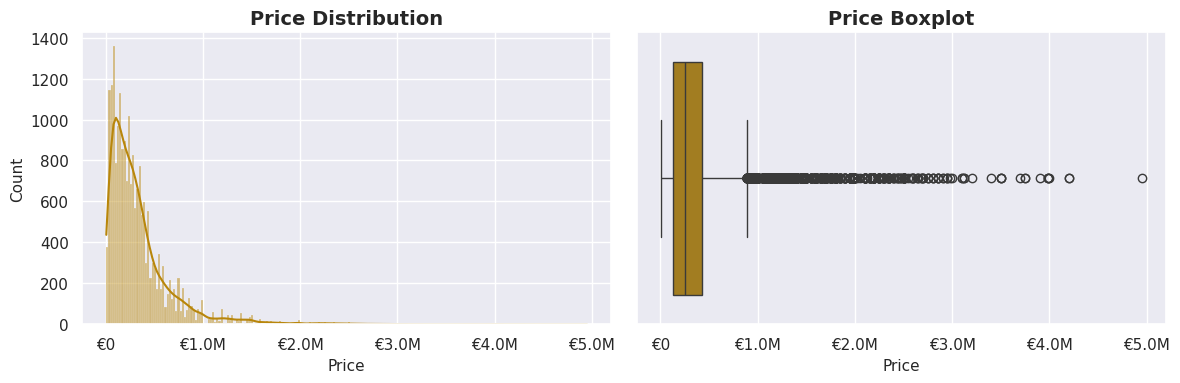

In [341]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="Price", ax=axes[0], kde=True)
axes[0].set_title("Price Distribution")
fmt_price_axis(axes[0])

sns.boxplot(data=df, x="Price", ax=axes[1])
axes[1].set_title("Price Boxplot")
fmt_price_axis(axes[1])

plt.tight_layout()
plt.show()

Wide range of prices that extend, given million euro value homes

We want to be able to predict those and eventually sell those kinds of properties so we will keep these in the model.

Our model will be trained on **up to 4.95 million euro value homes.**

Note: To support the model, price will be logged for training and fitting.

#### Price Per Square Meter

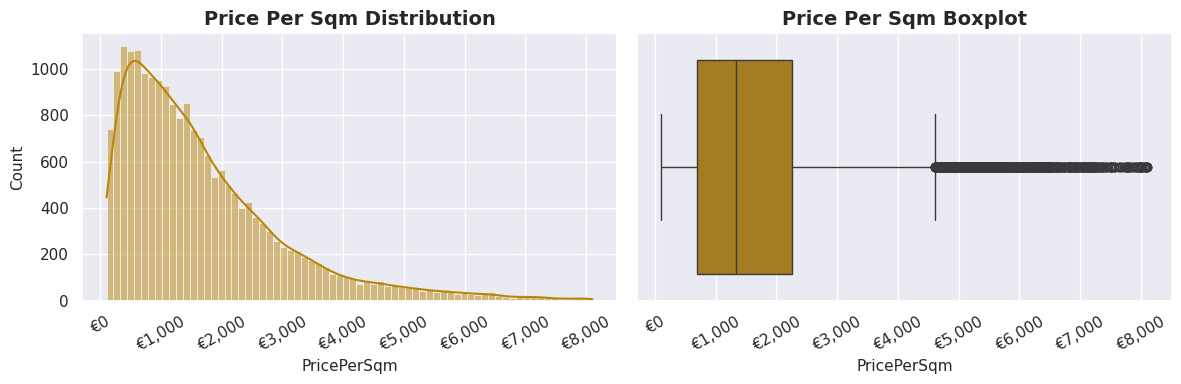

In [342]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="PricePerSqm", ax=axes[0], kde=True)
axes[0].set_title("Price Per Sqm Distribution")
fmt_price_axis(axes[0])
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="PricePerSqm", ax=axes[1])
axes[1].set_title("Price Per Sqm Boxplot")
fmt_price_axis(axes[1])
axes[1].tick_params(axis="x", rotation=30)


plt.tight_layout()
plt.show()

Most properties are within the range of typical 1000 to 2000 Euro price per square meter according to market research

### Geographical Data

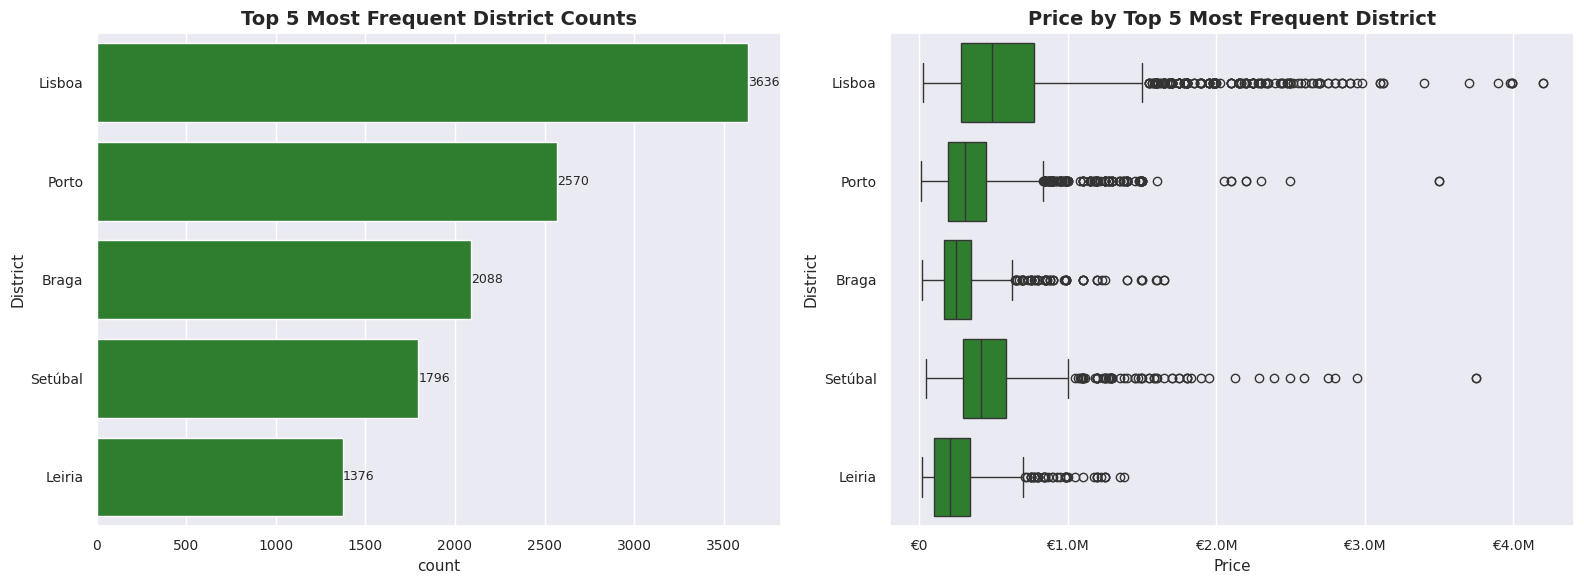

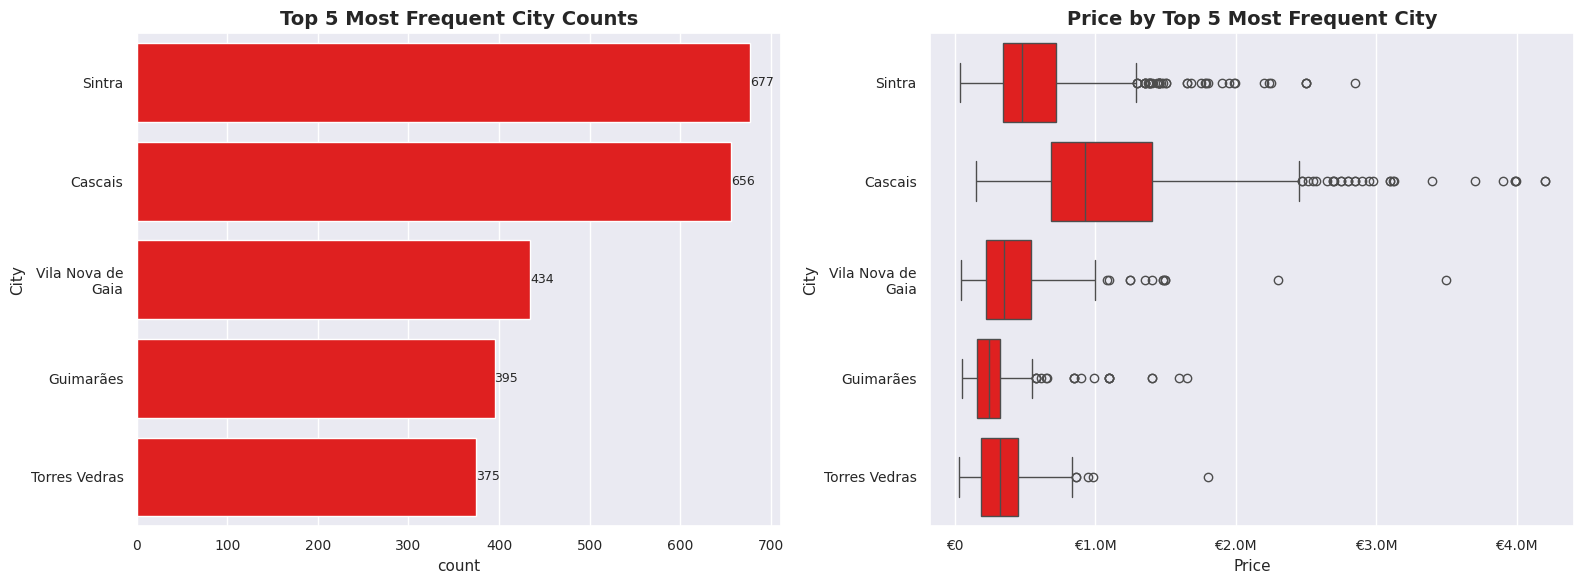

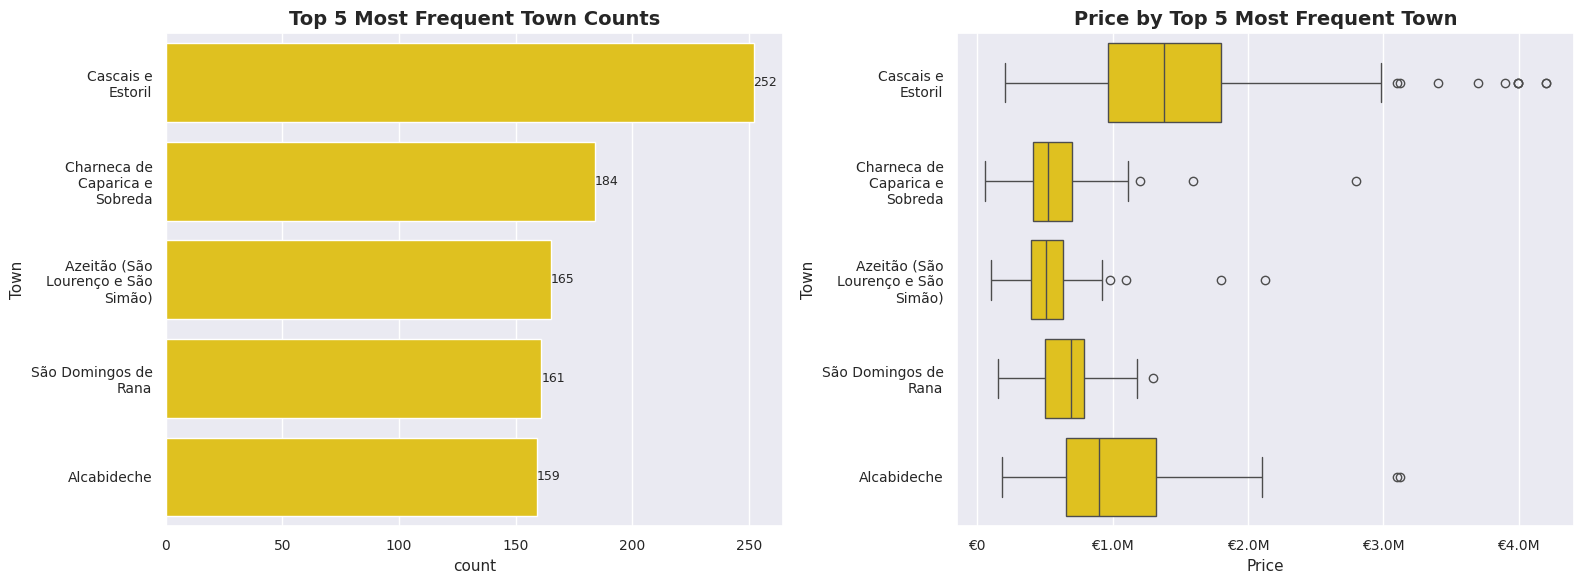

In [343]:
geo_vars = ["District", "City", "Town"]
geo_colors = ["forestgreen", "red", "gold"]

for i, col in enumerate(geo_vars):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    top5 = df[col].value_counts().nlargest(5).index
    ax1 = sns.countplot(data=df, y=col, order=top5, ax=ax1, color=geo_colors[i])

    for p in ax1.patches:
        width = p.get_width()
        ax1.annotate(
            f"{int(width)}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=9,
        )
    ax1.set_yticks(range(len(top5)))
    ax1.set_title(f"Top 5 Most Frequent {col} Counts")
    ax1.tick_params(labelsize=10)
    ax1.set_yticklabels([textwrap.fill(label, width=15) for label in top5])

    ax2.set_yticks(range(len(top5)))
    top5_subset = df[df[col].isin(top5)]
    ax2 = sns.boxplot(
        data=top5_subset, y=col, x="Price", order=top5, ax=ax2, color=geo_colors[i]
    )
    ax2.set_title(f"Price by Top 5 Most Frequent {col}")
    ax2.tick_params(labelsize=10)
    ax2.set_xlabel("Price")
    ax2.set_yticklabels([textwrap.fill(label, width=15) for label in top5])
    fmt_price_axis(ax2)

    plt.tight_layout()
    plt.show()

On the larger District scale, the district of Lisboa has the most properties and the highest values. It also contains most outliers that stretch the farthest.

In Cities, Cascais with the 2nd highest count of data has the highest value quartiles. It is known to be a premier upscale coastal town. This shows again in the Town data, with Cascais e Estoni having the highest values across both quartiles and outliers.

### Energy Certificate

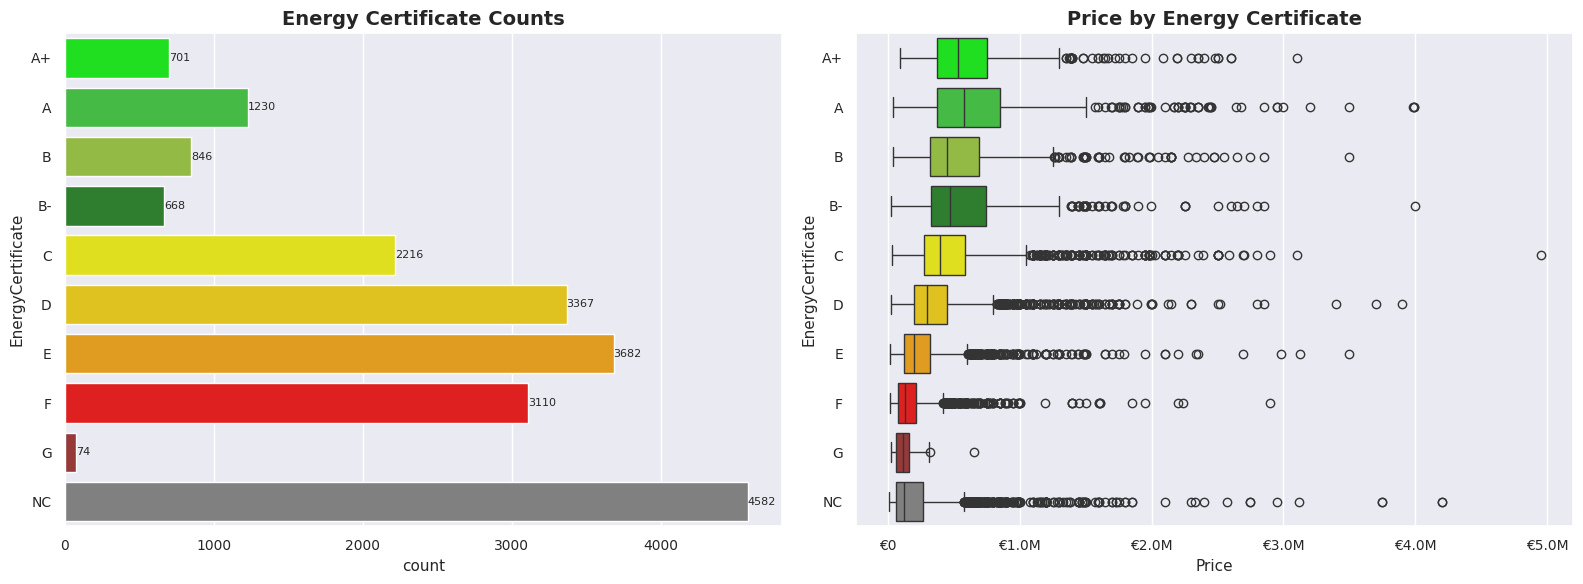

In [344]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

order = ["A+", "A", "B", "B-", "C", "D", "E", "F", "G", "NC"]
energy_palette = {
    "A+": "lime",
    "A": "limegreen",
    "B": "yellowgreen",
    "B-": "forestgreen",
    "C": "yellow",
    "D": "gold",
    "E": "orange",
    "F": "red",
    "G": "brown",
    "NC": "gray",
}

ax1 = sns.countplot(
    data=df,
    y="EnergyCertificate",
    order=order,
    ax=ax1,
    hue="EnergyCertificate",
    palette=energy_palette,
)

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(
        f"{int(width)}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=8,
    )

ax1.set_title("Energy Certificate Counts")
ax1.tick_params(labelsize=10)

ax2 = sns.boxplot(
    data=df,
    y="EnergyCertificate",
    x="Price",
    order=order,
    ax=ax2,
    hue="EnergyCertificate",
    palette=energy_palette,
)
ax2.set_title("Price by Energy Certificate")
ax2.tick_params(labelsize=10)
fmt_price_axis(ax2)

plt.tight_layout()
plt.show()

- Most houses that do have a certificate are of **medium-low certificate rating**, C to F.
- Houses with higher energy certificates, such as **grade A, tend to have higher pricing** and higher quartiles than middle to low grade.

### Area

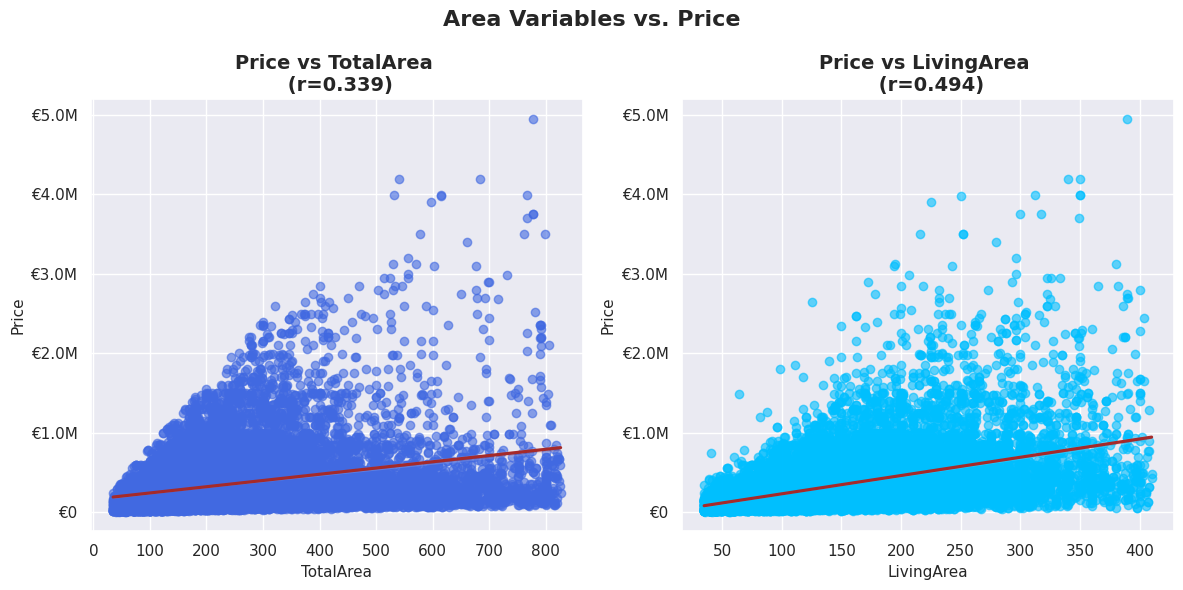

In [345]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, area_col in enumerate(area_vars):
    sns.regplot(
        data=df,
        x=area_col,
        y="Price",
        color=area_colors[i],
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "brown"},
    )
    axes[i].set_title(
        f"Price vs {area_col} \n (r={df[area_col].corr(df['Price']):.3f})"
    )
    axes[i].set_xlabel(area_col)
    axes[i].set_ylabel("Price")
    fmt_price_axis(axes[i])

plt.suptitle("Area Variables vs. Price")
plt.tight_layout()
plt.show()

- Large homes capitalize the higher pricing area with outliers. (More higher priced outliers in bigger homes)
- More clustering and intersection between price and area in the low hundreds 
- Both show moderate-weak relationship with price

### Construction Year

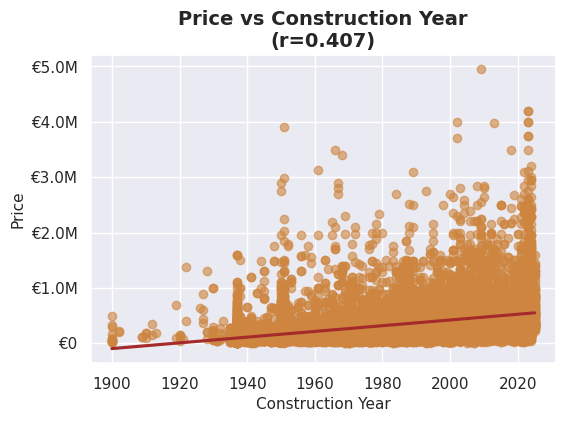

In [346]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x="ConstructionYear",
    y="Price",
    color="peru",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "brown"},
)
plt.title(
    f"Price vs Construction Year\n(r={df['ConstructionYear'].corr(df['Price']):.3f})"
)
plt.xlabel("Construction Year")
plt.ylabel("Price")
fmt_price_axis(plt.gca())
plt.show()

- Higher pricing clustering for more modern homes
- It is seemingly **rare in the data to have older homes** and they **remain on the lower price range.**

#### Room Variables

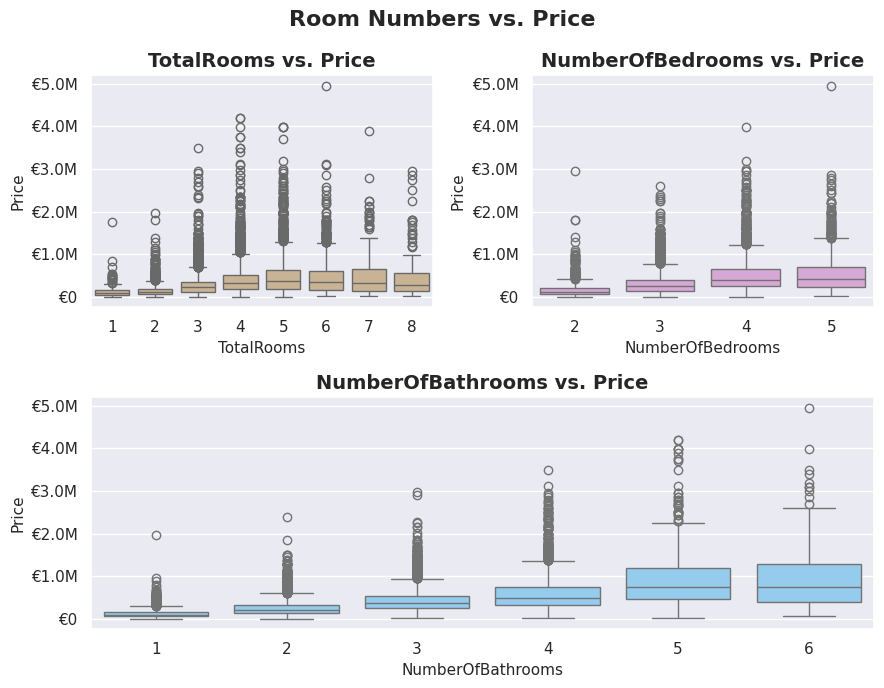

In [347]:
fig, axes = plt.subplot_mosaic("AB;CC", figsize=(9, 7))

for i, (key, var) in enumerate(zip("ABC", room_vars)):
    sns.boxplot(data=df, x=var, y="Price", ax=axes[key], color=room_colors[i])
    axes[key].set_title(f"{var} vs. Price")
    fmt_price_axis(axes[key])

plt.suptitle("Room Numbers vs. Price")
plt.tight_layout()
plt.show()

- **Steady increase in price quartiles** as number of these room variables increase (most noticeable in number of bathrooms)
- For TotalRooms and NumberOfBedrooms, middle amounts (5 rooms, 4/5 bedrooms) have the highest range. And most outliers are presently clustering in middle amount of rooms. 

#### Amenities

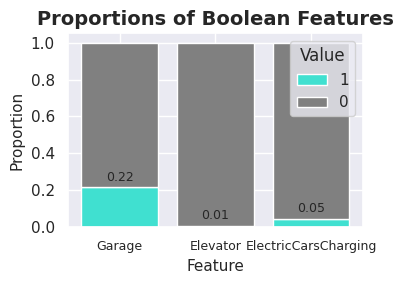

In [348]:
amenities = ["Parking", "Garage", "Elevator", "ElectricCarsCharging"]
proportions = df[bool_vars].mean()

plt.figure(figsize=(4, 3))

bars1 = plt.bar(proportions.index, proportions, label="1", color="turquoise")
bars0 = plt.bar(
    proportions.index, 1 - proportions, bottom=proportions, label="0", color="grey"
)

for i, feature in enumerate(proportions.index):
    plt.text(
        i,
        proportions[feature] + 0.02,
        f"{proportions[feature]:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xlabel("Feature")
plt.ylabel("Proportion")
plt.xticks(fontsize=9)
plt.legend(title="Value", loc="upper right")
plt.title("Proportions of Boolean Features")
plt.tight_layout()
plt.show()

Unsurprisingly, these are very rare amenities.

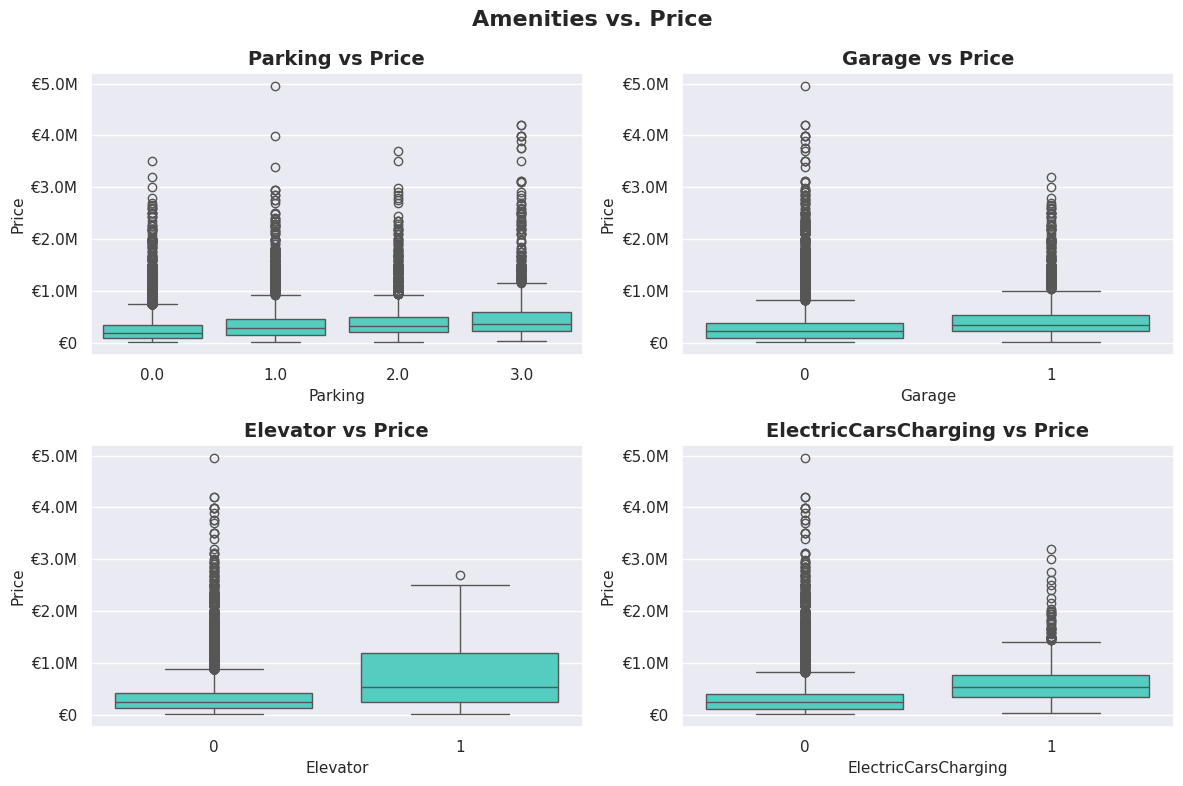

In [349]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(amenities):
    sns.boxplot(df, x=var, y="Price", ax=axes[i], color="turquoise")
    axes[i].set_title(f"{var} vs Price")
    fmt_price_axis(axes[i])

plt.suptitle("Amenities vs. Price")
plt.tight_layout()
plt.show()

- Parking
    - Homes with 1 parking have the highest price reach in outliers possibly because of having the most data
    - As number of parking increases then quartile values and medians increase slightly
- Houses with **rare amenities with garages, elevators, are guaranteed to have higher prices** . However they are underrepresented and it does not stretch as far in values through outliers.

### Correlations

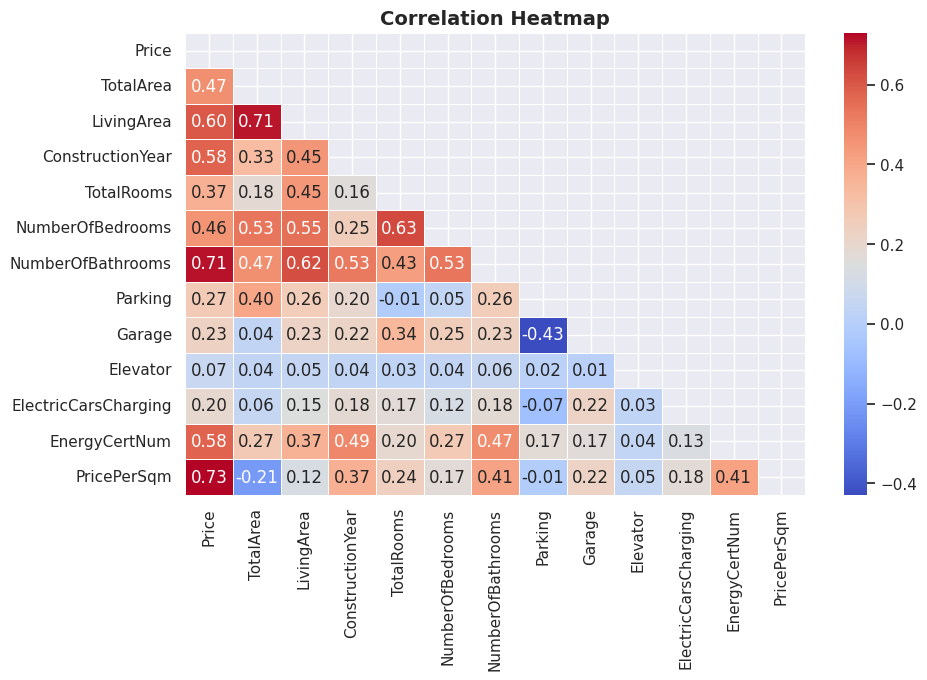

In [350]:
num_features = df.select_dtypes(include="number")

plt.figure(figsize=(10, 6))

corr = num_features.corr(method="spearman")
matrix = np.triu(corr)

sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The highest relationships with price are:


*(Excluding PricePerSqm which was directly based off it)*
| Variable | Correlation | Description |
|----------|-------------|-------------|
| NumberOfBathrooms | +0.71 | Our most complete variable on rooms is the strongest correlated |
| LivingArea | +0.60 | Livable space of a home, stronger correlation than total area (indoor livable space more correlated > total area which may include outdoor area) |
| ConstructionYear | +0.58 | Year and consequently age of a house shows moderate-strong relationship|
| EnergyCertNum | +0.58 | Energy certificate also has moderate-strong |

Weakest correlations are amenities

Among other variables, some notable correlations are:

| Variable | Correlation | Description |
|----------|-------------|-------------|
| Bedrooms & Bathrooms vs. LivingArea | +0.54, 0.62 | Strongly correlated with LivingArea, which again takes precedence over TotalArea as livable indoor measurement is more correlated |
| Garage vs. Parking | -0.44 | Most notable negative correlation. Garage covers parking measurements and inversely, more parking is needed when garage is absent |
| PricePerSqm vs. TotalArea | -0.20 | The bigger the property, the lower the price per sqm. Larger properties tend to have more empty and cheaper space, compared to small expensive city centre properties with high price per sqm but low total area |

**🗑️ For model learning: Addressing Correlations of < 0.20 and > 0.70**
- `TotalArea` will be dropped
    - Variable pairings with strong correlations of 0.70 and above will be addressed by dropping 1 of the variables.
    - LivingArea and TotalArea are at 0.70 and LivingArea, and since indoor livable space is more correlated with price, TotalArea will be dropped.
- Low correlations with price (< 0.20) will be dropped:
    - `Elevator` & `ElectricCarsCharging` dropped during model learning.

## 3. Statistical Inference

### 3.0 Target Population

The target population of this dataset encompasses all **potential buyers of Portugal house properties**, of a varying price range **from potential luxury home owners, to those looking to buy smaller average priced homes.**

### 🔎 3.1 Statistical Hypothesis & Testing

**Focus variables: `District`, `City`, `Town`** (Geographic Variables)

In this statistics section, our focus variables that we will view against our target variable `Price` will be the three geographic variables.

1. **Do the different geographical levels and location of a property have an effect on price?** 
2. And if so, **which geographical scale has the most significance with Price?**

#### 🧪 Hypothesis:

* **H₀** (null hypothesis) - **Property price is not affected by geographical variables**. 
* **Hₐ** (alternative hypothesis) - **Property prices *do* differ significantly across locations at one or more geographical scales.**

**α=0.05**

Our significance threshold will be 0.05. 

P-values below this are statistically significant.

#### 3.1.1 Significance

**Kruskal-Wallis H test**

Given multiple independent samples across districts, cities, and towns, this test can ascertain whether Price distributions differ significantly across the grouped samples.

In [351]:
for var in geo_vars:
    groups = [group["Price"].values for name, group in df.groupby(var)]
    statistic, p_value = stats.kruskal(*groups)
    print(f"{var}: p = {p_value:.10f}")

District: p = 0.0000000000
City: p = 0.0000000000
Town: p = 0.0000000000


With such significant p-values we reject the null hypothesis. **Price does differ with geographical location on all scales** and has strong predictive power.

#### 3.1.2 Effect Sizes & Confidence Intervals

Observing **Epsilon-squared (ε²)** which is a measure of **effect size** and shows how much variation in Price is explained by each geographical level.
- measures proportion of variance in a dependent variable explained by an independent variable
- Higher values closer to 1 indicate a stronger effect
- It takes the following calculations for the formula:

$$\varepsilon^2 = \frac{H - k + 1}{n - k}$$

Where:
- $\varepsilon^2$ = epsilon-squared (effect size)
- $H$ = Kruskal-Wallis test statistic
- $k$ = number of groups (number of unique values per geo var) 
- $n$ = total number of properties (length of df)

In [352]:
geo_stats = pd.DataFrame(
    columns=["Level", "Groups", "H", "p", "ε² Lower", "ε² Upper", "ε²"]
)

for var in geo_vars:
    groups = [group["Price"].values for name, group in df.groupby(var)]
    stat, p = kruskal(*groups)
    k = len(groups)
    n = len(df)

    eps2 = (stat - k + 1) / (n - k)

    h_var = 2 * stat**2 / n
    se_h = np.sqrt(h_var)
    se_eps2 = se_h / (n - k)

    ci = stats.t.interval(confidence=0.95, df=n - 1, loc=eps2, scale=se_eps2)
    ci_lower = max(0, ci[0])
    ci_upper = min(1, ci[1])

    new_row = pd.DataFrame(
        {
            "Level": [var],
            "Groups": [k],
            "H": [f"{stat:.2f}"],
            "p": [f"{p:.4f}"],
            "ε² Lower": [f"{ci_lower:.3f}"],
            "ε² Upper": [f"{ci_upper:.3f}"],
            "ε²": [f"{eps2:.3f}"],
        }
    )
    geo_stats = pd.concat([geo_stats, new_row], ignore_index=True)

geo_stats

,Level,Groups,H,p,ε² Lower,ε² Upper,ε²
0,District,25,7685.84,0.0000,0.367,0.382,0.375
1,City,267,10625.20,0.0000,0.502,0.523,0.513
2,Town,1962,13017.40,0.0000,0.584,0.611,0.597


* We can be 95% confident that the effect size between Price & geographical variable lies within the epsilon intervals above. The intervals have no overlapping and bounds do not stretch more than ~0.030 for good confidence.
* **The biggest effect variable is Town, closely followed by City**. District is the least with a larger distance between the previous 2.

#### Stat Testing Conclusion:
* Geographical locations, on all scales District, City, and Town, do have a very significant impact on Pricing with p-values = 0.
* The smallest geographical scale, Town, has the biggest effect with City next.
* Follows this trend that **the more specific the variable location the bigger the effect size on price**. 

## 4. Data Preprocessing

### 4.0 Splitting the Data

**75/12.5/12.5**

With ~20,000 data points and hyperparamater tuning in mind, the data will be split into 3 sets for validation tuning.

In [353]:
df.shape

(20476, 17)

🗑️ Dropping from model learning:
- `TotalArea` which was strongly correlated to LivingArea (+0.71) to reduce dimensionality
- Dropping `Elevator` & `ElectricCarsCharging` the least correlated to price can help with noise and unneeded data
- `PricePerSqm` which was used for cleaning and analysis only.

In [354]:
X = df.drop(
    [
        "Price",
        "PricePerSqm",
        "EnergyCertificate",
        "TotalArea",
        "Elevator",
        "ElectricCarsCharging",
    ],
    axis=1,
)
y = df["Price"]

In [355]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}\nVal: {X_val.shape}\nTest: {X_test.shape}")

Train: (15357, 11)
Val: (2559, 11)
Test: (2560, 11)


### 4.1 Logging Target Variable

Price is heavily right-skewed, with luxury homes kept in our pricing offers. To keep these luxury deals but at the same time make accurate predictions: the outliers and right tail will be compressed by applying log1p.

**Logging Price** will help address skew - taking the log of price means that errors in predicting expensive houses and cheap houses will affect the result equally.

While Trees, Forests and Boosting do not require feature scaling, the models can still benefit from logging and this will help not to over-invest in fitting the luxury outliers. Models can also better learn proportional errors that make sense for all home values over tending errors to absolute higher-priced properties.

*Note:* 
- *Log will be used for model input (fitting)*
- *Inverse (base price) will be used for output interpretation (scoring) to see original € scale*

In [356]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

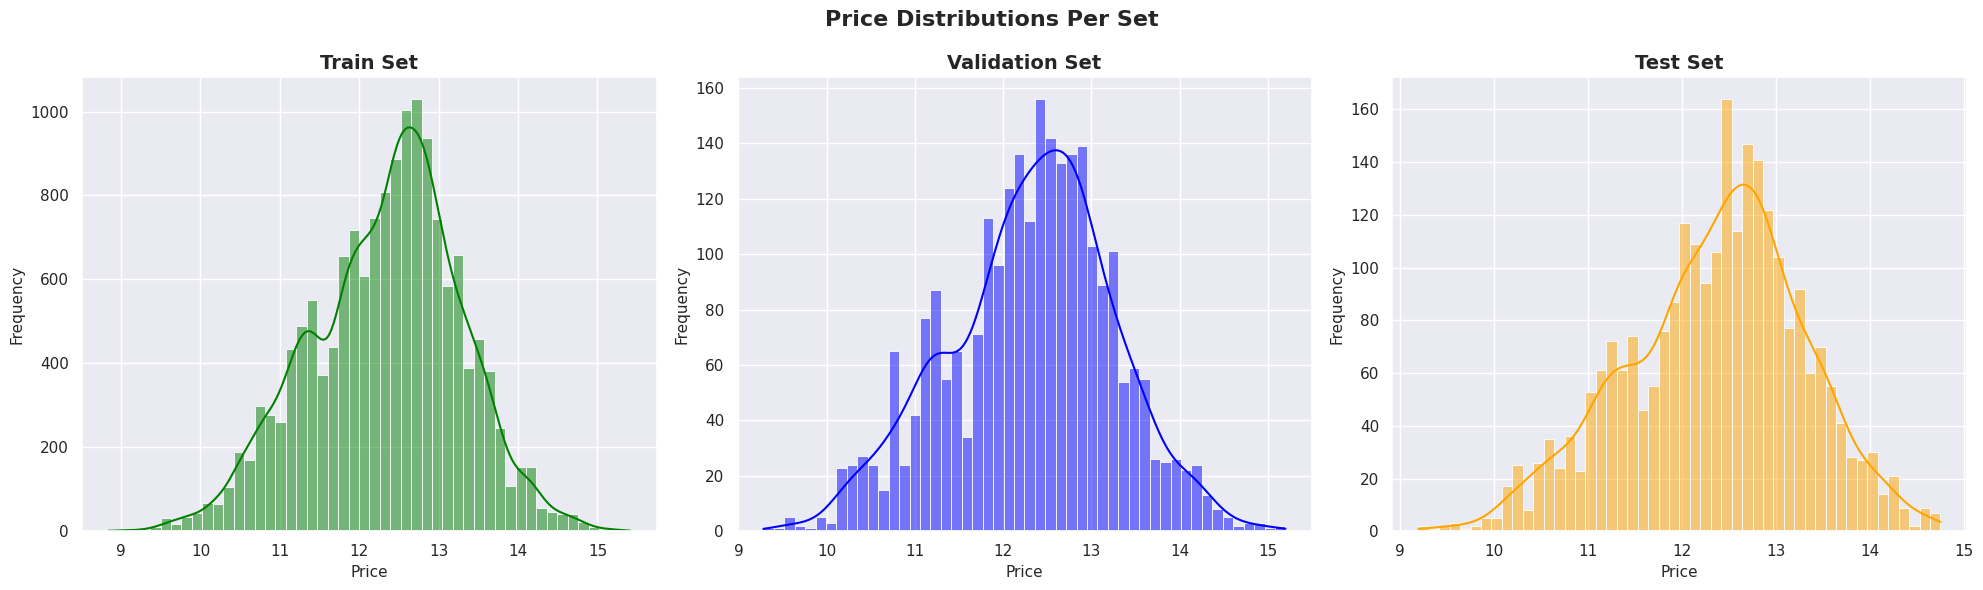

In [357]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sets = {"Train": y_train_log, "Validation": y_val_log, "Test": y_test_log}
colors = ["green", "blue", "orange"]

for ax, (name, data), color in zip(axes, sets.items(), colors):
    sns.histplot(data, bins=50, kde=True, color=color, ax=ax)
    ax.set_title(f"{name} Set")
    ax.set_xlabel("Price")
    ax.set_ylabel("Frequency")

plt.suptitle("Price Distributions Per Set")
plt.tight_layout()
plt.show()

### 🔧 4.3 Pipeline
1. Categorical Features (Geographical)
- Chosen Imputer: `SimpleImputer` to mark "Missing" - missing data means an unknown location and will be kept unknown.
- Chosen Encoder: `TargetEncoder` - this encoder can capture the location's relationship with price; geographic data with higher property values get higher codes

2. Numerical Features
* Correlated Variables (Rooms) 
    * Chosen Imputer: `IterativeImputer` - Captures directional relationships between room vars and makes use of complete bathroom data to impute between data in a round robin fashion
* Other Num Features 
    * Chosen Imputer: `Median` - robust value to outliers rather than mean

In [358]:
num_features = X.select_dtypes(include=["number"]).columns
corr_nums = ["NumberOfBathrooms", "TotalRooms", "NumberOfBedrooms"]
other_nums = [col for col in num_features if col not in corr_nums]
cat_features = ["District", "City", "Town"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="constant", fill_value="Missing"),
                    ),
                    (
                        "encoder",
                        TargetEncoder(
                            smooth="auto", target_type="continuous", random_state=42
                        ),
                    ),
                ]
            ),
            cat_features,
        ),
        (
            "corr_num",
            Pipeline(
                steps=[("imputer", IterativeImputer(max_iter=10, random_state=42))]
            ),
            corr_nums,
        ),
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            other_nums,
        ),
    ],
    remainder="drop",
)

preprocessor.set_output(transform="pandas")

X_train_p = preprocessor.fit_transform(X_train, y_train_log)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

## 5. Model Building

* Main metric: **Mean Absolute Error (MAE)**
    * We will use **MAE as our main measure of model performance** to measure the average magnitude of errors between predicted and actual values. **MAE is less sensitive to the outliers** we have in our data than RMSE or R squared. *These other metrics will still be listed and available.*
* Baseline measure model: Median DummyRegressor
    * The median is to be observed as it is more robust to outliers and more fitting for our skewed price data than following the mean
* Initial model: Random Forest
    * Our initial model will be a Random Forest model with default values and parameters.

### 5.0 Baseline

Starting with a prompt look at a trivial baseline / "Do-Nothing" baseline as our benchmark.

In [359]:
baseline_median = DummyRegressor(strategy="median")
baseline_median.fit(X_train_p, y_train_log)

y_pred_train = np.expm1(baseline_median.predict(X_train_p))
y_pred_val = np.expm1(baseline_median.predict(X_val_p))

results, new_results = score_predictions(
    y_pred_train, y_pred_val, y_train, y_val, "Median Baseline", {"strategy": "median"}
)
new_results

/home/linuxg/Desktop/Turing/cgarci-DS.v2.5.3.2.5/utils.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)


,Model,MAE,Train MAE,RMSE,R2,Params
0,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


Our baseline MAE is €211,439.208

### 5.1 Random Forest - Initial Model

In [360]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=42)),
    ]
)

rf_pipeline.fit(X_train, y_train_log)

y_pred_train = np.expm1(rf_pipeline.predict(X_train))
y_pred_log = rf_pipeline.predict(X_val)
y_pred_val = np.expm1(y_pred_log)

results, new_results = score_predictions(
    y_pred_train, y_pred_val, y_train, y_val, "Base Random Forest", "Defaults", results
)
new_results

,Model,MAE,Train MAE,RMSE,R2,Params
0,Base Random Forest,"€84,825.663","€52,222.252","€166,623.784",0.776,Defaults
1,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


Already a major improvement from the baseline by ~127k in MAE.

#### 5.1.2 Predicted vs. Actual - Initial Model

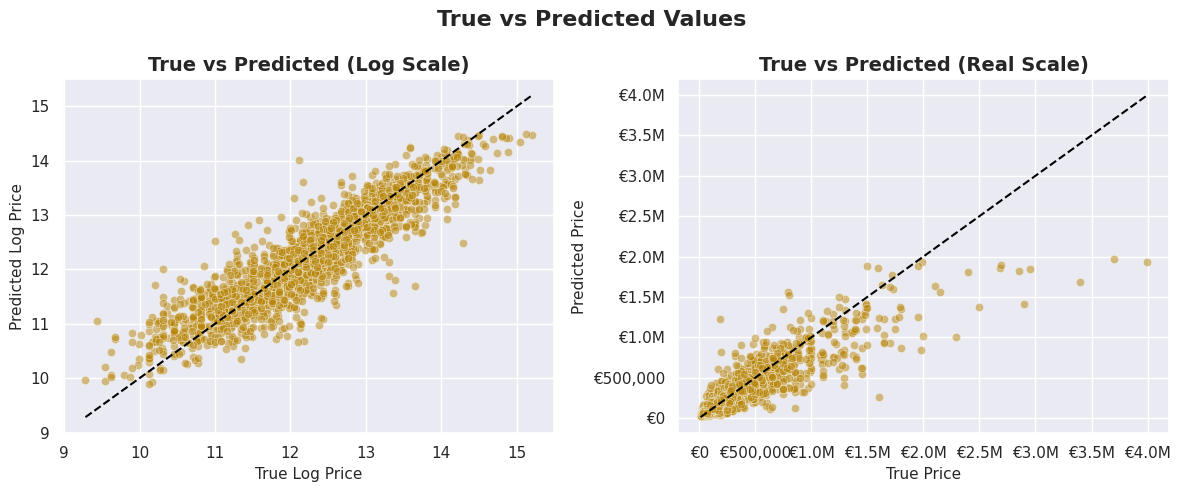

In [361]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_val_log, y=y_pred_log, alpha=0.5, ax=ax1)
sns.lineplot(
    x=[y_val_log.min(), y_val_log.max()],
    y=[y_val_log.min(), y_val_log.max()],
    color="black",
    linestyle="--",
    ax=ax1,
)
ax1.set_xlabel("True Log Price")
ax1.set_ylabel("Predicted Log Price")
ax1.set_title("True vs Predicted (Log Scale)")

sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.5, ax=ax2)
sns.lineplot(
    x=[y_val.min(), y_val.max()],
    y=[y_val.min(), y_val.max()],
    color="black",
    linestyle="--",
    ax=ax2,
)
ax2.set_xlabel("True Price")
ax2.set_ylabel("Predicted Price")
ax2.set_title("True vs Predicted (Real Scale)")
fmt_price_axis(ax2, force_x=True, force_y=True)

plt.suptitle("True vs Predicted Values")
plt.tight_layout()
plt.show()

*(The log-space plot on the left shows the models quality where it was actually trained and fit (log-transformed price). The currency plot on the right is mostly for interpretation of errors in real monetary value.)*

Model shows strong predictive performance in the log space where it was trained and fit.

Viewing in currency value there is mostly underpredictions than overpredictions in luxury value homes.

### 5.2 Boosted Models

This sprint introduced Gradient Boosting models - an ensemble technique where models build upon correcting subsequent errors of previous learners to minimize a loss function (in this case it is MAE). The following 2 Gradient Boosted models will be explored here:
1. Light Gradient Boosting 
2. Extreme Gradient Boosting 

In [362]:
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Light Gradient Boosting": LGBMRegressor(random_state=42, verbose=-1),
    "Extreme Gradient Boosting": XGBRegressor(random_state=42),
}

#### Default / out of the box models

In [363]:
for name, model in models.items():
    # Skip RF, Base RF was already checked
    if "Random Forest" in name:
        continue

    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train_log)

    y_pred_train = np.expm1(pipeline.predict(X_train))
    y_pred_val = np.expm1(pipeline.predict(X_val))

    results, new_results = score_predictions(
        y_pred_train, y_pred_val, y_train, y_val, f"Base {name}", "Defaults", results
    )

new_results

,Model,MAE,Train MAE,RMSE,R2,Params
0,Base Random Forest,"€84,825.663","€52,222.252","€166,623.784",0.776,Defaults
1,Base Light Gradient Boosting,"€90,638.605","€82,328.162","€175,590.706",0.751,Defaults
2,Base Extreme Gradient Boosting,"€90,952.863","€70,895.054","€176,541.738",0.749,Defaults
3,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


* With no tuning involved, the **best out of the box model actually remains to be the initial Random Forest model**.       
    * However comparing the train and validation MAE scores suggests that it ***needs tuning the most and does not necessarily generalize the best.*** The default RF, with max_depth=None, will need to be constrained 

- Light Boosting's default has the smallest gap and lower variance. 
- XGB slightly outperforms Light Boosting with defaults.

#### Tuned Models - Bayesian Optimization

**Bayesian Optimization with Optuna** was utilized to find the best parameters. `n_trials=50` and cross fold validation were used.

*Checked parameters and best parameters can be found in `utils.py`:*
- Used param grid: `search_spaces`
- Best params from the grid were encoded to a dictionary: `best_params`

In [364]:
best_params = {
    "Random Forest": {
        "max_depth": 10,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": 0.6312037280884872,
        "criterion": "absolute_error",
        "max_samples": 0.8,
        "n_estimators": 230,
    },
    "Light Gradient Boosting": {
        "max_depth": -1,
        "num_leaves": 150,
        "subsample": 0.8034004048764889,
        "min_child_samples": 5,
        "n_estimators": 994,
        "objective": "regression_l1",
        "learning_rate": 0.03,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.01,
    },
    "Extreme Gradient Boosting": {
        "max_depth": 10,
        "learning_rate": 0.018084743750431353,
        "subsample": 0.8337755132348706,
        "min_child_weight": 3,
        "n_estimators": 997,
        "objective": "reg:absoluteerror",
        "reg_lambda": 5,
        "gamma": 1,
        "tree_method": "hist",
    },
}

# use if tuning is needed:
if not best_params:
    best_params = tune_models(
        models, search_spaces, X_train, y_train_log, y_train, preprocessor, n_trials=50
    )
    best_params

Notable params:
- Objectives that directly optimize MAE were used and worked best (objectives: absolute error / regression l1), chosen over hybrid criterions such as huber.
- Params that allow **complex learning** were preferred: 
    - long training with large n_estimators were set for both with 1000 estimators and **early stopping**
    - **Small learning rates for slow learning and more trees** needed for better generalizations 
    - **High feature diversity** in colsample bytree
    - Forms of regularization and constraints through parameters like reg_lamba and min_child_weight for more conservative instances. 

In [365]:
best_model, best_mae, best_name = None, float("inf"), None

for name, model in models.items():
    pipeline = make_pipeline_boilerplate(preprocessor, type(model), best_params[name])
    pipeline.fit(X_train, y_train_log)

    y_pred_train = np.expm1(pipeline.predict(X_train))
    y_pred_val = np.expm1(pipeline.predict(X_val))

    results, new_results = score_predictions(
        y_pred_train,
        y_pred_val,
        y_train,
        y_val,
        f"Tuned {name}",
        best_params[name],
        results,
    )

    current_mae = results.loc[results["Model"] == f"Tuned {name}", "MAE"].iloc[-1]
    if current_mae < best_mae:
        best_mae, best_name, best_model = current_mae, name, pipeline

print(f"\n🏆 Best model after tuning: {best_name} with MAE: €{best_mae:.4f}")


🏆 Best model after tuning: Light Gradient Boosting with MAE: €83470.6872


In [366]:
new_results

,Model,MAE,Train MAE,RMSE,R2,Params
0,Tuned Light Gradient Boosting,"€83,470.687","€56,195.581","€165,004.207",0.781,"{'max_depth': -1, 'num_leaves': 150, 'subsampl..."
1,Tuned Extreme Gradient Boosting,"€84,384.574","€55,989.137","€167,408.637",0.774,"{'max_depth': 10, 'learning_rate': 0.018084743..."
2,Base Random Forest,"€84,825.663","€52,222.252","€166,623.784",0.776,Defaults
3,Tuned Random Forest,"€90,009.650","€78,554.372","€178,463.735",0.743,"{'max_depth': 10, 'min_samples_split': 4, 'min..."
4,Base Light Gradient Boosting,"€90,638.605","€82,328.162","€175,590.706",0.751,Defaults
5,Base Extreme Gradient Boosting,"€90,952.863","€70,895.054","€176,541.738",0.749,Defaults
6,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


- Constraining Random Forest with MAE criterions and controlled complexity (effectively closed the gap between Train and Val MAE) actually worsened its MAE; it needed more complex, deep diverse trees to have a lower MAE score. 
- Both boosting models are within the same range across the scoring: around €83k MAE. Boosting had better sequential correction with its tuned hyperparameters rather than its defaults.
- Tuned Light Boosting outperforms Extreme boosting by a barely slight edge. Light Boosting also shows better scores across all metrics, better RMSE and better R2 slightly.

### 5.3 Stacking Ensemble

We can combine the best models so far to possibly achieve even better results through a stacked generalization ensemble. 

Stacking the best parameters of all top 3 models: Tuned RF + Tuned GB + Tuned XGB

In [367]:
rf = RandomForestRegressor(**best_params["Random Forest"], random_state=42, n_jobs=-1)
lgb = LGBMRegressor(
    **best_params["Light Gradient Boosting"], random_state=42, verbosity=-1
)
xgb = XGBRegressor(**best_params["Extreme Gradient Boosting"], random_state=42)

stacking_optimized = StackingRegressor(
    estimators=[("rf", rf), ("lgb", lgb), ("xgb", xgb)]
)

pipeline_stacked = Pipeline(
    [("preprocessor", preprocessor), ("regressor", stacking_optimized)]
)
pipeline_stacked.fit(X_train, y_train_log)
y_pred_train = np.expm1(pipeline_stacked.predict(X_train))
y_pred_val = np.expm1(pipeline_stacked.predict(X_val))

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    "Stacked RF+LGB+XGB",
    "Best params of RF, LGB & XGB",
    results,
)
new_results

,Model,MAE,Train MAE,RMSE,R2,Params
0,Tuned Light Gradient Boosting,"€83,470.687","€56,195.581","€165,004.207",0.781,"{'max_depth': -1, 'num_leaves': 150, 'subsampl..."
1,Stacked RF+LGB+XGB,"€83,602.167","€55,786.095","€163,037.210",0.786,"Best params of RF, LGB & XGB"
2,Tuned Extreme Gradient Boosting,"€84,384.574","€55,989.137","€167,408.637",0.774,"{'max_depth': 10, 'learning_rate': 0.018084743..."
3,Base Random Forest,"€84,825.663","€52,222.252","€166,623.784",0.776,Defaults
4,Tuned Random Forest,"€90,009.650","€78,554.372","€178,463.735",0.743,"{'max_depth': 10, 'min_samples_split': 4, 'min..."
5,Base Light Gradient Boosting,"€90,638.605","€82,328.162","€175,590.706",0.751,Defaults
6,Base Extreme Gradient Boosting,"€90,952.863","€70,895.054","€176,541.738",0.749,Defaults
7,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


The meta learner **competes closely with the top models but is 2nd best in MAE**. It does not outperform possibly due to the models having nearly identical structure with focus in hyperparameters and other tuning, resulting in identical splits, residuals, errors and many more that does not give the meta learner much to differentiate and improve on.

### 🏆️ 5.4 Final Results

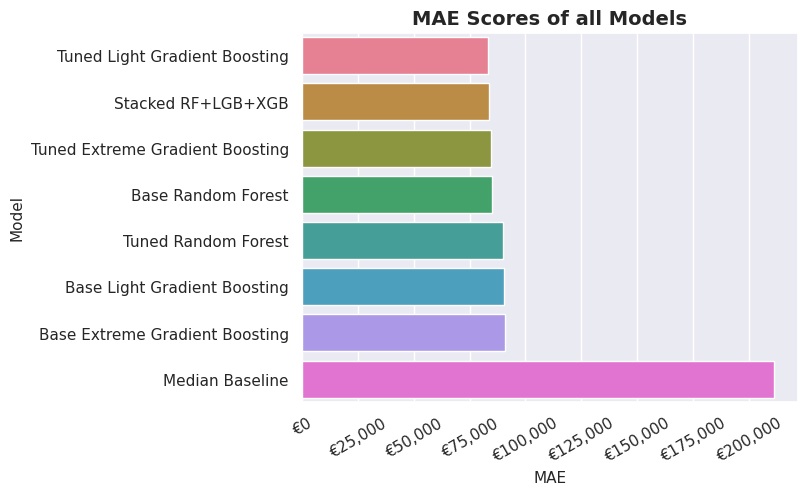

In [368]:
ax = sns.barplot(
    results.sort_values("MAE", ascending=False).iloc[::-1],
    x="MAE",
    y="Model",
    hue="Model",
)
plt.title("MAE Scores of all Models")
fmt_price_axis(ax)
plt.xticks(rotation=30)
plt.show()

In [369]:
new_results

,Model,MAE,Train MAE,RMSE,R2,Params
0,Tuned Light Gradient Boosting,"€83,470.687","€56,195.581","€165,004.207",0.781,"{'max_depth': -1, 'num_leaves': 150, 'subsampl..."
1,Stacked RF+LGB+XGB,"€83,602.167","€55,786.095","€163,037.210",0.786,"Best params of RF, LGB & XGB"
2,Tuned Extreme Gradient Boosting,"€84,384.574","€55,989.137","€167,408.637",0.774,"{'max_depth': 10, 'learning_rate': 0.018084743..."
3,Base Random Forest,"€84,825.663","€52,222.252","€166,623.784",0.776,Defaults
4,Tuned Random Forest,"€90,009.650","€78,554.372","€178,463.735",0.743,"{'max_depth': 10, 'min_samples_split': 4, 'min..."
5,Base Light Gradient Boosting,"€90,638.605","€82,328.162","€175,590.706",0.751,Defaults
6,Base Extreme Gradient Boosting,"€90,952.863","€70,895.054","€176,541.738",0.749,Defaults
7,Median Baseline,"€211,439.208","€216,377.486","€362,712.510",-0.061,{'strategy': 'median'}


* **Best MAE:** Light Gradient Boosting
    * The lowest MAE comes from Light Gradient Boosting, showing its efficiency as a singular lightweight model to achieve the best MAE score.

To help make a sure and confident final decision on which to deploy, the performance on the test set can be observed between the 2 ctop close competitors:

In [370]:
y_pred_stacked = np.expm1(pipeline_stacked.predict(X_test))
y_pred_lgbm = np.expm1(best_model.predict(X_test))

print("Stacked MAE:", mean_absolute_error(y_test, y_pred_stacked))
print("LGBM MAE:", mean_absolute_error(y_test, y_pred_lgbm))

Stacked MAE: 85473.58372768977
LGBM MAE: 85528.51353254539


On the test set, the stacked model still does not outperform LGB model. There is also only a €100 - €250 difference. 

* 🏆️ **Best Chosen Model:** Tuned Light Gradient Boosting
    * Over all the models and scores, Light Gradient Boosting will be the deployed model as it achieved the best work and displayed superior performance in its **simplicity and efficiency as a singular model outperforming the rest**. 
        * Lowest MAE overll, and RMSE for a singular boosted model, and higher R2 than XGB. Overall competed closely with Stacked model and XGB
    * This also makes for practical deployment, LGB's lower demands for production, and quicker yet accurate performance will be chosen over the complexity, sizing, and timing of a stacked model. Even if the stacked model had the best MAE slightly, LGBM would still be the chosen model to deploy given its practicality.

Saving the best chosen model: *(only run once when needed)*

In [ ]:
# joblib.dump(best_model, "api/lgbm_model.pkl")
# print("🖨️ Model saved to api/lgbm_model.pkl")

🖨️ Model saved to api/lgbm_model.pkl


## 6. Model Evalution 

Moving on to final testing using the hold-out test set.

### 6.1 Scoring on Test Set

In [372]:
y_pred_train = np.expm1(best_model.predict(X_train))
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

del results
results, new_results = score_predictions(
    y_pred_train,
    y_pred,
    y_train,
    y_test,
    "(Best) Tuned Light Gradient Boosting",
    best_params[best_name],
)
new_results

/home/linuxg/Desktop/Turing/cgarci-DS.v2.5.3.2.5/utils.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)


,Model,MAE,Train MAE,RMSE,R2,Params
0,(Best) Tuned Light Gradient Boosting,"€85,528.514","€56,195.581","€157,375.032",0.78,"{'max_depth': -1, 'num_leaves': 150, 'subsampl..."


* Around the same consistent performance range on Test MAE as with validation 
* Same distance range between Test MAE and Train (~30,000) as with validation set

### 6.2 Residuals

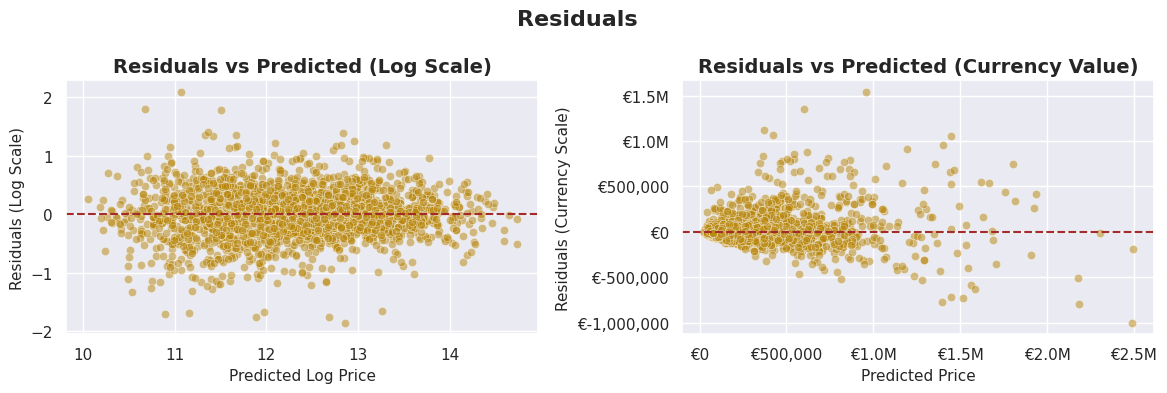

In [373]:
residuals_log = y_test_log - y_pred_log
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.5, ax=ax1)
ax1.axhline(0, color="brown", linestyle="--")
ax1.set_xlabel("Predicted Log Price")
ax1.set_ylabel("Residuals (Log Scale)")
ax1.set_title("Residuals vs Predicted (Log Scale)")

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=ax2)
ax2.axhline(0, color="brown", linestyle="--")
ax2.set_xlabel("Predicted Price")
ax2.set_ylabel("Residuals (Currency Scale)")
ax2.set_title("Residuals vs Predicted (Currency Value)")
fmt_price_axis(ax2, force_x=True, force_y=True)

plt.suptitle("Residuals")
plt.tight_layout()
plt.show()

*(The log-space plot on the left shows the models quality where it was actually trained and fit (log-transformed price). The currency plot on the right is mostly for interpretation of errors in real monetary value.)*

Log Scale (Left):
- Residuals are randomly scattered with no clear pattern suggesting the model has captured the main relationships.
- Variance seems roughly constant throughout the scale. Uncertainty does not increase or decrease with the target magnitude.

Currency Scale (Right):
- Less accurate in absolute terms for expensive properties with wider negative residuals, suggesting underpredictions in luxury properties and that the model cannot fully capture data on expensive properties that supposedly pulls pricing upwards.

### 6.3 True vs Predicted Values

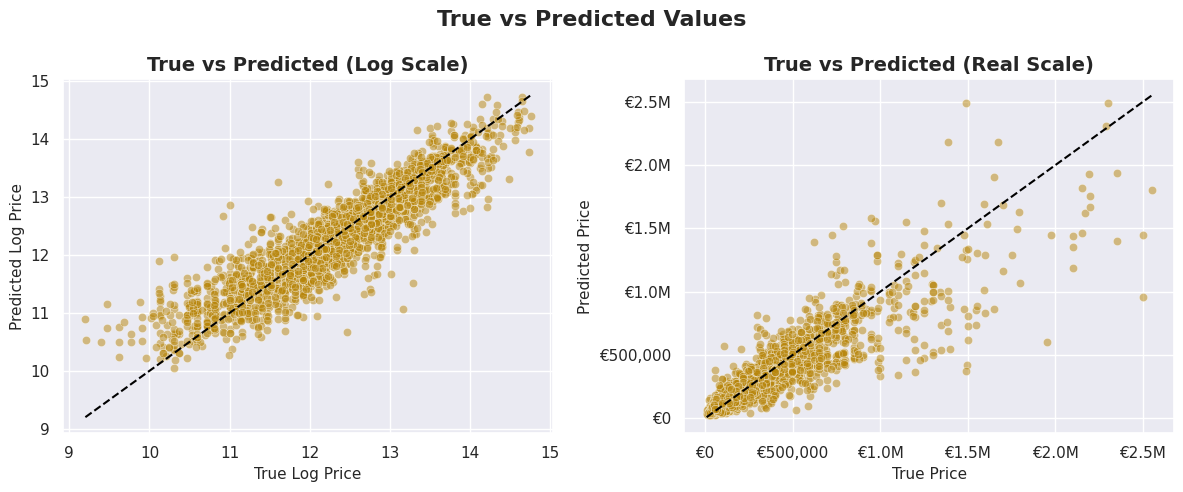

In [374]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_test_log, y=y_pred_log, alpha=0.5, ax=ax1)
sns.lineplot(
    x=[y_test_log.min(), y_test_log.max()],
    y=[y_test_log.min(), y_test_log.max()],
    color="black",
    linestyle="--",
    ax=ax1,
)
ax1.set_xlabel("True Log Price")
ax1.set_ylabel("Predicted Log Price")
ax1.set_title("True vs Predicted (Log Scale)")

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax2)
sns.lineplot(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    color="black",
    linestyle="--",
    ax=ax2,
)
ax2.set_xlabel("True Price")
ax2.set_ylabel("Predicted Price")
ax2.set_title("True vs Predicted (Real Scale)")
fmt_price_axis(ax2, force_x=True, force_y=True)

plt.suptitle("True vs Predicted Values")
plt.tight_layout()
plt.show()

*(The log-space plot on the left shows the models quality where it was actually trained and fit (log-transformed price). The currency plot on the right is mostly for interpretation of errors in real monetary value.)*

**Log Scale (Left):**
- Overprediction points at the lower end of the data perhaps due to sparse unusual low-priced properties.
- Captured general trend of the data with strong performance
- Model is predicting well across the full range and cluster around the diagonal of perfect prediction line.

**Currency Scale (Right):**
- Even spread between overprediction and underprediction, with slightly more points visible on the underpredicted side.

### 6.4 Feature Importance

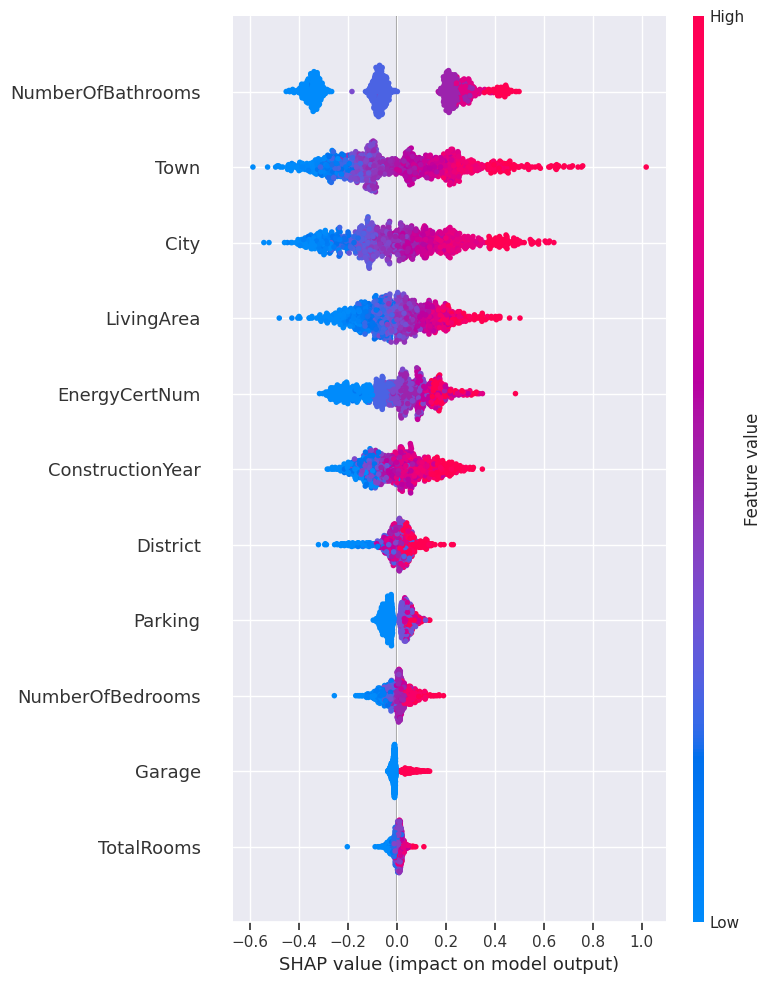

In [375]:
explainer = shap.TreeExplainer(best_model.named_steps["regressor"])

sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42).reset_index(drop=True)
X_test_transformed = preprocessor.transform(X_test_sample)

shap_values = explainer(X_test_transformed)

feature_names = preprocessor.get_feature_names_out()
feature_names_clean = [name.split("__")[-1] for name in feature_names]

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_clean,
    plot_size=(8, 10),
)

The top 5 most important features that drove predictions of our Light Gradient Boosting Model are:

|  | Feature            | Analysis                                                                 |
|-----:|-------------------|-----------------------------------------------------------------------------|
| #5    | 💡 EnergyCertNum | Energy efficiency strongly correlates with price predictive power            |
| #4    | 📏 LivingArea    | The total livable area measurement of a home is 4th important for the model's pricing predictions.          |
| #3    | 🗺️ City             | The middle geographical scale is the 3rd driver for price <br> **Geographical variables take hold of 2 feature importance spots**. Overall location is extremely important for price <br> Location can determine higher or lower prices in equal measure.      |
| #2    | 🗺️ Town             | The smallest geographical scale is the 2nd strongest driver for predicting price. <br> This follows the trend seen earlier in the statistical testing portion where smaller scales have bigger effect. <br>Higher-priced towns are more likely. <br> **The highest observed impacts** actually occur here in Town for **highest SHAP impact**                                          |
| #1    | 🔢 NumberOfBathrooms | Essentially our proxy variable for overall number of rooms, property size and functionality - all these details it can suggest makes it the strongest driver for price levels     |

### Sample Predictions

Viewing model predictions on a singular random sample 42: 

In [376]:
idx = 42
predicted = y_pred[idx]
actual = y_test.iloc[idx]
error = predicted - actual

info = pd.DataFrame(
    {
        "Feature": ["Predicted", "Actual", "Difference", "% Off"] + feature_names_clean,
        "Value": [
            f"€{predicted:,.0f}",
            f"€{actual:,.0f}",
            f"€{error:,.0f}",
            f"{error/actual*100:.1f}%",
            *shap_values.data[idx],
        ],
    }
).set_index("Feature")

info.T

Feature,Predicted,Actual,Difference,% Off,District,City,Town,NumberOfBathrooms,TotalRooms,NumberOfBedrooms,LivingArea,ConstructionYear,Parking,Garage,EnergyCertNum
Value,"€364,711","€349,000","€15,711",4.5%,13.028662,13.20638,13.308907,5.0,5.147908,4.0,370.0,2023.0,0.0,1.0,9.0


Waterfall plot

Viewing the model's detailed breakdown of feature importance for this sample:

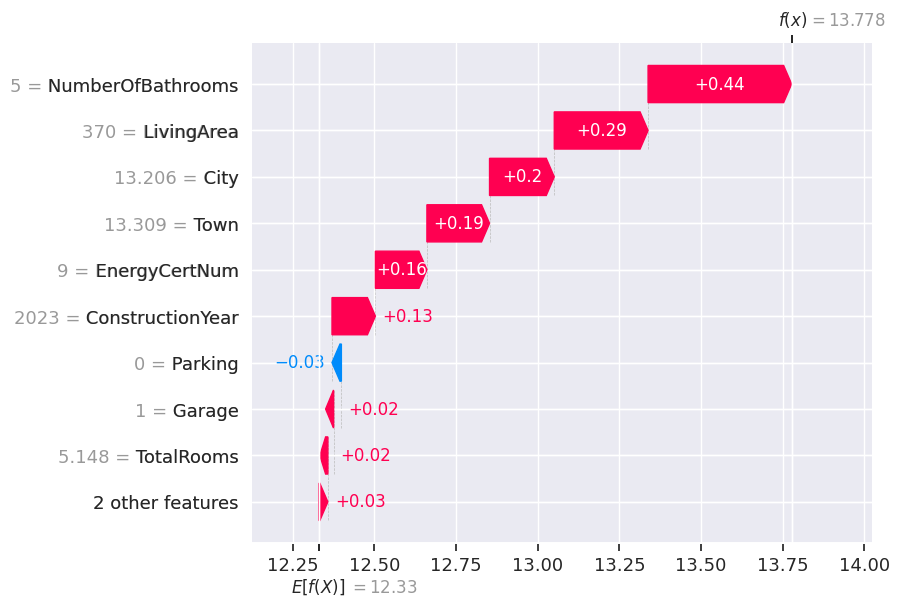

In [377]:
shap_exp = shap.Explanation(
    values=shap_values.values[idx],
    base_values=shap_values.base_values[idx],
    data=shap_values.data[idx],
    feature_names=feature_names_clean,
)
shap.plots.waterfall(shap_exp, max_display=10)

Model's prediction is €364,711 / and remarkably only narrowly off by 4.5% on a singular sample from the test set. The house 's 5 bathrooms are the #1 feature for predictions, next to its livable space area measurement, City location and Town, and then its A+ energy certificate.

## 7. Conclusion

*Suggestions for Further Research:*
- Price cap / budget limit could benefit the model to train within only a specific pricing range
- Data Collection & Scraping - Desirable Features:
    - Outdoor variables - more common and expensive outdoor house amenities such as Pools, Gardens might be more common and more useful for the model than current amenities such as Elevators. 
    - NumberOfFloors variable - important for multi-floor house properties and relation to price (expected that multi-story properties are more expensive)
- Without file size, complexity and other constraints, Random Forest could be improved and could contribute to the ensemble score as well

**🔎 Findings:**
* In statistical testing, all geographical values were found to be statistically significant. The smallest scale, Town, had the strongest Epsiolon-squared effect followed by the next scale in size City and then District. 
* Random Forests are a strong default contender for this housing data, with the base model competing with the top tuned performers. However when RF was tuned for MAE and bayesian optimization it showed worse performance
* 🏆️ Best Models: 
    * Light Gradient Boosting Model was the best performing singular tuned model and competed closely with the meta learner from the Stacked model.
    * Averaging predictions in a stacked model showed minimal improvements and was not an overall good trade-off to deploy its complexity
* The 5 most important features for pricing are:
    1. NumberOfBathrooms - Essentially our proxy variable for overall number of rooms, property size and functionality - all these details it can suggest makes it the strongest driver for price levels in our deployed LGB model
    2. Town - smallest and most specific geographical scale is 2nd important driver.
    3. City - geographical variables take hold of 2 feature importance spots. Overall location of a house in Portugal is extremely important for pricing predictions. 
    4. LivingArea - measurable indoor livable space is 4th important.
    5. EnergyCertNum - the energy certificate of a house and its efficiency according to Portugal standards lend strong prediction for price points
* The model was successfully deployed [here](https://house-pricing-api-428580420970.europe-west1.run.app/docs).